# PD Summary — One-shot QC + DSB Proximity Interpretation (ONT)

This notebook is designed to be **run top-to-bottom** and then shared (export to HTML/PDF if desired).

It will:
1. Explain the expected input format
2. Load all `*_summary.csv` / `*_collapsed_summary.csv` in the PD folder
3. Run QC and CIS/TRANS summaries with statistical testing (T0 vs cut time point)
4. Show DSB insertion locations on a yeast chromosome map
5. Generate TRANS repair contact heatmaps and a circos plot of top associations
6. (Optionally) save all plots and summary tables to a local `Outputs/` folder

---

## Sequencing platform: Oxford Nanopore Technology (ONT)

This PD data was generated using **long-read Oxford Nanopore Technology (ONT)** sequencing. Key implications for analysis:

- ONT long reads span entire repair junctions, providing **direct phase information** about which two DSB ends joined.
- The higher raw error rate of ONT (R9.4/R10 chemistries, ~97–99.5% modal accuracy) is mitigated by deep coverage; alignments are filtered by mapping quality.
- Because ONT reads a full molecule, allele assignment based on flanking unique sequences is more reliable than short-read approaches that may require overlapping paired-end reads.
- Long reads are especially powerful for detecting **inter-chromosomal TRANS ligation products** that would span regions too far apart for short-read pairs to bridge confidently.

---

## Biological context (Aim 3)

This PD dataset is interpreted in the same framework as the 3C and 4C analyses:

- Two simultaneous **site-specific DSBs** are induced (by I-SceI or Cas9) at defined yeast genomic loci.
- Repair by **non-homologous end joining (NHEJ)** or **SSA** can occur in *cis* (cognate DSB ends re-ligate) or in *trans* (non-cognate ends join).
- Published work (Haber lab; Lottersberger *et al.* 2015 *Mol Cell*; Lisby *et al.* 2004 *Nat Cell Biol*) demonstrates that DSBs **migrate to shared nuclear foci** (repair centers) within minutes, bringing otherwise distant loci together.
- If post-damage co-localization dominates, TRANS repair frequency should be relatively **insensitive to pre-damage inter-locus distance** — consistent with your Aim 2/3 model.
- The key PD readout is therefore **which allele/locus partners are captured together over time**, not merely whether damage occurred.

---

## Data location

This notebook reads from `WILSONTEW_PD_FOLDER` if set; otherwise it falls back to `./PD_Data`.

Recommended PD folder:
```
C:/Users/dunnmk/University of Michigan Dropbox/MED-WILSONTELAB/wilsontelab box/Common/Projects/Yeast Aim 3/Sequencing/PD Data
```

DSB insertion positions are loaded from:
```
data/raw/Insertion_Primers_for_Locations_of_DSBs.csv
```
(preferred; legacy fallback is the workspace root).

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(scales)
})

# Handle optional packages gracefully
has_ggrepel <- requireNamespace('ggrepel', quietly = TRUE)
if (!has_ggrepel) {
  message('Note: ggrepel not available; installing...')
  install.packages('ggrepel', quiet = TRUE)
  suppressPackageStartupMessages(library(ggrepel))
} else {
  suppressPackageStartupMessages(library(ggrepel))
}

# Optional: circlize for circos plots
has_circlize <- requireNamespace('circlize', quietly = TRUE)
if (!has_circlize) {
  message('Note: circlize not available; install with -> install.packages("circlize")')
} else {
  suppressPackageStartupMessages(library(circlize))
}

Note: circlize not available; install with -> install.packages("circlize")



In [2]:
# ---- Load DSB insertion positions from primer CSV ----
primer_csv_candidates <- c(
  file.path(getwd(), 'data', 'raw', 'Insertion_Primers_for_Locations_of_DSBs.csv'),
  file.path(getwd(), 'Insertion_Primers_for_Locations_of_DSBs.csv'),
  file.path(getwd(), 'data', 'csv', 'Insertion_Primers_for_Locations_of_DSBs.csv')
)
dsb_csv_path <- primer_csv_candidates[file.exists(primer_csv_candidates)][1]
if (is.na(dsb_csv_path) || is.null(dsb_csv_path)) dsb_csv_path <- primer_csv_candidates[1]

# S. cerevisiae SacCer3 chromosome lengths (bp) for genomic plots
saccer3_chrom_lengths <- tibble::tibble(
  Chromosome = c('I','II','III','IV','V','VI','VII','VIII','IX','X','XI','XII','XIII','XIV','XV','XVI'),
  Length     = c(230218L, 813184L, 316620L, 1531933L, 576874L, 270161L,
                 1090940L, 562643L, 439888L, 745751L, 666816L, 1078177L,
                 924431L, 784333L, 1091291L, 948066L),
  Chrom_Num  = 1:16
)

dsb_locs <- tibble::tibble()

if (file.exists(dsb_csv_path)) {
  dsb_raw <- readr::read_csv(dsb_csv_path, show_col_types = FALSE)

  # The CSV has two identically-named "Chromosome Coordinate" columns (start/end).
  # read_csv auto-renames them; rename them cleanly by position.
  coord_cols <- grep('Chromosome Coordinate', names(dsb_raw), value = TRUE)
  if (length(coord_cols) >= 2) {
    names(dsb_raw)[names(dsb_raw) == coord_cols[1]] <- 'Coord_Start'
    names(dsb_raw)[names(dsb_raw) == coord_cols[2]] <- 'Coord_End'
  }

  # Extract chromosome from Primer Name (e.g. "III_L02_FWD" -> roman numeral prefix)
  dsb_locs <- dsb_raw %>%
    filter(Orientation == 'FWD') %>%
    mutate(
      Chromosome   = stringr::str_extract(`Primer Name`, '^[IVX]+'),
      DSB_Num      = as.integer(Location),
      Coord_Start  = as.integer(Coord_Start),
      Coord_End    = as.integer(Coord_End),
      Coord_Mid    = as.integer((Coord_Start + Coord_End) / 2L),
      Primer_Locus_Label = stringr::str_extract(`Primer Name`, '^[IVX]+_L[0-9]+(?:_[0-9]+)?_(?:FWD|REV)'),
      Primer_Locus_Label = dplyr::if_else(
        !is.na(Primer_Locus_Label),
        Primer_Locus_Label,
        paste0(Chromosome, '_L', sprintf('%02d', DSB_Num), '_FWD')
      ),
      DSB_Label    = paste0('DSB', sprintf('%02d', DSB_Num), '_Chr', Chromosome),
      Gene_Label   = paste0(`Gene Name`, ' (DSB', sprintf('%02d', DSB_Num), ')')
    ) %>%
    left_join(saccer3_chrom_lengths, by = 'Chromosome') %>%
    arrange(Chrom_Num, Coord_Mid)

  message('Loaded ', nrow(dsb_locs), ' DSB insertion positions across ',
          n_distinct(dsb_locs$Chromosome), ' chromosomes.')
  print(dsb_locs %>% select(DSB_Num, Primer_Locus_Label, Chromosome, Coord_Start, Coord_End,
                             `Gene Name`, `Primer Name`))
} else {
  warning(paste0(
    'Primer CSV not found. Expected at: ',
    paste(primer_csv_candidates, collapse = ' | ')
  ))
}

New names:
• `Chromosome Coordinate` -> `Chromosome Coordinate...5`
• `Chromosome Coordinate` -> `Chromosome Coordinate...6`
Loaded 28 DSB insertion positions across 5 chromosomes.



# A tibble: 28 × 7
   DSB_Num Primer_Locus_Label Chromosome Coord_Start Coord_End `Gene Name`    
     <int> <chr>              <chr>            <int>     <int> <chr>          
 1       2 III_L02_FWD        III              37616     37835 APA1           
 2       3 III_L03_FWD        III             130281    130744 SAT4           
 3       4 III_L04_FWD        III             289797    293178 Uncharacterized
 4       1 IV_L01_FWD         IV                7814      8682 SOR2           
 5       3 IV_L03_FWD         IV              130002    130406 RPL41A         
 6       6 IV_L06_2_FWD       IV              244981    245132 YDL121C        
 7       8 IV_L08_FWD         IV              340282    340627 RPS29B         
 8      10 IV_L10_2_FWD       IV              492324    492555 RPS11A         
 9      13 IV_L13_FWD         IV              712994    713339 MTC6           
10      12 IV_L12_2_FWD       IV              913924    914316 YDR214W        
# ℹ 18 more rows
# ℹ 1 more varia

## Expected columns (typical)
Most PD summary CSVs include columns like:
- `batch`, `time_point`, `DSB`, `allele`, `combo`, `cis_trans`, `count`
Optional but supported:
- `repeat` (e.g., INTACT/SSA)
- `replicate`
- `alignment_name`

If any optional columns are missing, we will add reasonable defaults.

### Interpretation note
In this workflow, the important signal is **DSB partner usage by allele/locus over time**. 
That means "trans" should be read as **non-cognate partnering behavior** in this assay context, and then integrated with your broader DSB movement/proximity hypothesis.

In [3]:
# ---- Locate PD folder ----
pd_folder_env <- Sys.getenv('WILSONTEW_PD_FOLDER', unset = '')

# Find project root by walking upward until expected project markers are found
find_project_root <- function(start_dir, max_up = 6) {
  cur <- normalizePath(start_dir, winslash = '/', mustWork = FALSE)
  for (i in seq_len(max_up + 1)) {
    markers <- c(
      file.path(cur, 'data', 'raw', 'Input_Data', 'PD_data'),
      file.path(cur, 'README.md'),
      file.path(cur, '.git')
    )
    if (any(file.exists(markers) | dir.exists(markers))) return(cur)
    parent <- dirname(cur)
    if (identical(parent, cur)) break
    cur <- parent
  }
  normalizePath(start_dir, winslash = '/', mustWork = FALSE)
}

project_root <- find_project_root(getwd())

pd_folder_candidates <- c(
  if (nzchar(pd_folder_env)) pd_folder_env else NULL,
  file.path(project_root, 'PD_Data'),
  file.path(project_root, 'data', 'raw', 'Input_Data', 'PD_data')
)

pd_folder_candidates <- unique(normalizePath(pd_folder_candidates, winslash = '/', mustWork = FALSE))
pd_folder <- pd_folder_candidates[1]
message('Project root guess: ', project_root)
message('PD folder candidates: ', paste(pd_folder_candidates, collapse = ' | '))

find_pd_files <- function(folder) {
  if (!dir.exists(folder)) return(character(0))
  list.files(
    folder,
    pattern = '(_summary|_collapsed_summary)\\.csv$',
    full.names = TRUE,
    recursive = TRUE,
    ignore.case = TRUE
  ) %>%
    .[stringr::str_detect(basename(.), regex('PD|collapsed_summary', ignore_case = TRUE))] %>%
    unique()
}

files <- character(0)
for (cand in pd_folder_candidates) {
  cand_files <- find_pd_files(cand)
  if (length(cand_files) > 0) {
    pd_folder <- cand
    files <- cand_files
    break
  }
}

if (length(files) == 0) {
  dir.create(pd_folder, recursive = TRUE, showWarnings = FALSE)
  stop(paste0(
    'No *_summary.csv or *_collapsed_summary.csv files found in any PD candidate folder:\n  - ',
    paste(pd_folder_candidates, collapse = '\n  - '),
    '\n\nFix: copy the PD summary CSVs into one of these folders, or set WILSONTEW_PD_FOLDER to the directory that contains them.'
  ))
}

message('Using pd_folder: ', pd_folder)
message('Found ', length(files), ' PD file(s).')
head(files, 10)

Project root guess: C:/Users/dunnmk/wilsontew-data-analysis

PD folder candidates: C:/Users/dunnmk/wilsontew-data-analysis/PD_Data | C:/Users/dunnmk/wilsontew-data-analysis/data/raw/Input_Data/PD_data

Using pd_folder: C:/Users/dunnmk/wilsontew-data-analysis/data/raw/Input_Data/PD_data

Found 4 PD file(s).



[1] "C:/Users/dunnmk/wilsontew-data-analysis/data/raw/Input_Data/PD_data/batch6_T0_PD_UMI_plus_singletons_collapsed_summary.csv"  
[2] "C:/Users/dunnmk/wilsontew-data-analysis/data/raw/Input_Data/PD_data/batch6_T180_PD_UMI_plus_singletons_collapsed_summary.csv"
[3] "C:/Users/dunnmk/wilsontew-data-analysis/data/raw/Input_Data/PD_data/batch8_T0_PD_UMI_plus_singletons_collapsed_summary.csv"  
[4] "C:/Users/dunnmk/wilsontew-data-analysis/data/raw/Input_Data/PD_data/batch8_T180_PD_UMI_plus_singletons_collapsed_summary.csv"

In [4]:
# ---- Read and combine ----
read_one <- function(f) {
  dat <- readr::read_csv(f, show_col_types = FALSE)
  if (!("repeat" %in% names(dat))) dat <- dplyr::mutate(dat, `repeat` = "ALL")
  if (!("replicate" %in% names(dat))) dat <- dplyr::mutate(dat, replicate = "ALL")
  if (!("alignment_name" %in% names(dat))) dat <- dplyr::mutate(dat, alignment_name = NA_character_)
  dat <- dplyr::mutate(
    dat,
    source_path = f,
    source_dir = dirname(f),
    allele = as.character(.data[["allele"]]),
    combo = as.character(.data[["combo"]]),
    cis_trans = as.character(.data[["cis_trans"]]),
    DSB = as.character(.data[["DSB"]]),
    `repeat` = as.character(.data[["repeat"]]),
    replicate = as.character(.data[["replicate"]]),
    batch = as.character(.data[["batch"]])
  )
  dat
}

dat_raw <- purrr::map_dfr(files, read_one)
dat_raw <- dplyr::mutate(dat_raw, batch = factor(batch, levels = sort(unique(batch))))
dplyr::glimpse(dat_raw)

Rows: 659
Columns: 13
$ batch          <fct> 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6…
$ DSB2_loci      <chr> "chr4", "chr4", "chr4", "chr4", "chr4", "chr4", "chr4",…
$ time_point     <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ replicate      <chr> "1", "1", "1", "1", "1", "1", "1", "1", "1", "1", "1", …
$ alignment_name <chr> "CIS_DSB1_FULL_CHRIII_L02", "CIS_DSB1_FULL_CHRIII_L03",…
$ cis_trans      <chr> "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS", "CIS",…
$ DSB            <chr> "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1", "DSB1",…
$ combo          <chr> "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to_B", "A_to…
$ `repeat`       <chr> "INTACT", "INTACT", "INTACT", "INTACT", "INTACT", "INTA…
$ allele         <chr> "CHRIII_L02", "CHRIII_L03", "CHRIII_L04", "CHRIV_L01", …
$ count          <dbl> 51283, 38174, 228463, 49541, 32857, 54088, 39551, 44777…
$ source_path    <chr> "C:/Users/dunnmk/wilsontew-data-analysis/data/raw/Input…
$ source_dir     <

In [5]:
# ---- Quick sanity tables ----
dat_raw %>%
  count(batch, time_point, DSB, sort = TRUE, name = 'n_rows') %>%
  head(30)


batch,time_point,DSB,n_rows
<fct>,<dbl>,<chr>,<int>
6,180,TRANS,80
8,180,TRANS,79
6,0,TRANS,57
6,0,DSB1,52
6,180,DSB1,52
6,180,DSB2,52
8,0,DSB1,52
8,180,DSB1,52
8,180,DSB2,52


## Priority kinetics line graphs (interpret first)

These line plots are intentionally placed **early** because they directly reflect the core biological interpretation from your sketch:

1. **CIS vs TRANS trajectories** over time (by batch).
2. **% intact**, **% repaired**, and **% SSA** trajectories (when repeat-state labels are available).

Interpret these before deeper locus-level maps, since they summarize the dominant repair behavior over time.

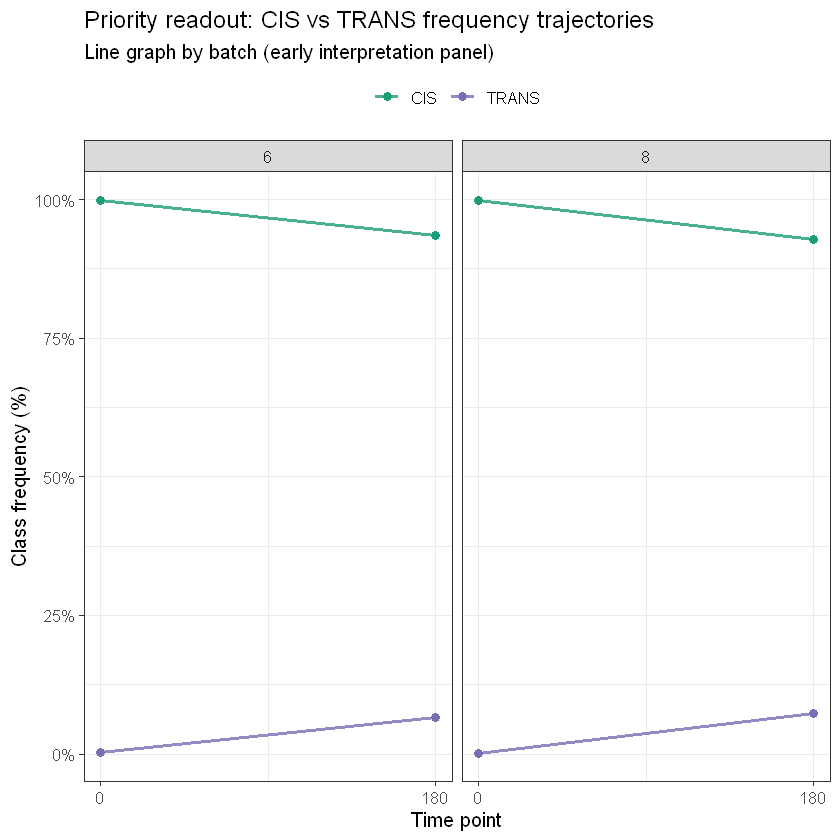

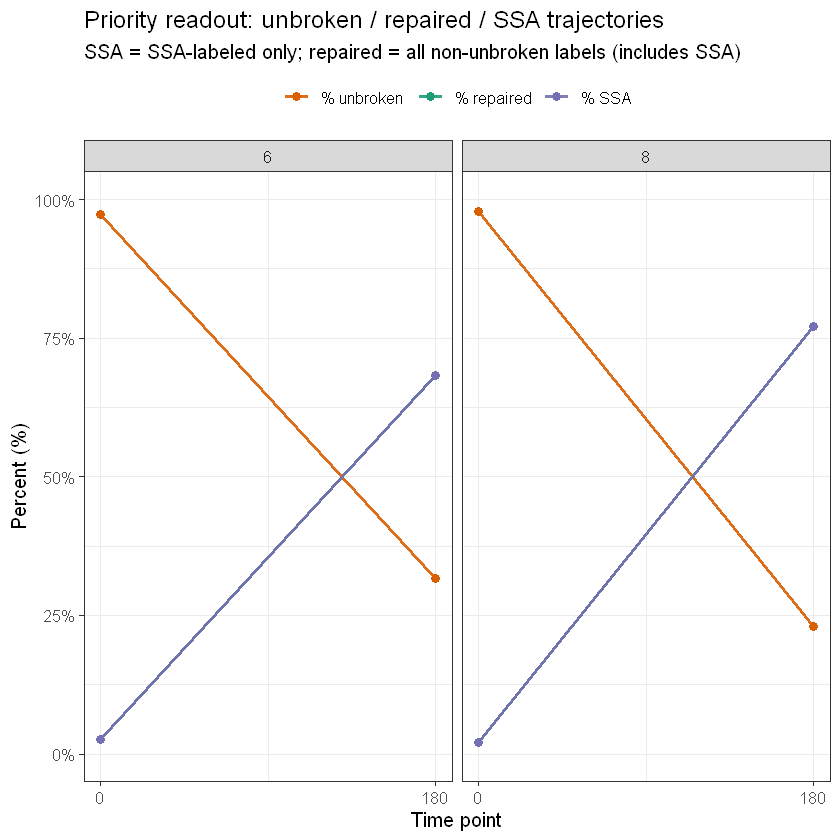

In [6]:
# ---- Priority kinetics line plots (early readout) ----
p_early_cistrans <- NULL
p_early_repair <- NULL

if (!exists('dat_raw') || nrow(dat_raw) == 0) {
  warning('dat_raw is empty. Run the data-loading cells first.')
} else {
  if (!exists('combos_4')) combos_4 <- c('A_to_B', 'C_to_D', 'A_to_D', 'C_to_B')
  if (!exists('cis_combos')) cis_combos <- c('A_to_B', 'C_to_D')
  if (!exists('trans_combos')) trans_combos <- c('A_to_D', 'C_to_B')

  dat_early <- dat_raw %>%
    mutate(
      batch = as.character(batch),
      tp_label = as.character(time_point),
      tp_num = suppressWarnings(readr::parse_number(as.character(time_point))),
      combo = as.character(combo),
      cis_trans = toupper(trimws(as.character(cis_trans)))
    )

  if (all(is.na(dat_early$tp_num))) {
    tp_levels_chr <- sort(unique(dat_early$tp_label))
    dat_early <- dat_early %>%
      mutate(tp_num = as.numeric(factor(tp_label, levels = tp_levels_chr)))
  }

  tp_axis <- dat_early %>%
    select(tp_num, tp_label) %>%
    filter(!is.na(tp_num), !is.na(tp_label), tp_label != '') %>%
    distinct() %>%
    arrange(tp_num)

  # 1) CIS vs TRANS trajectories over time (matches sketch intent)
  ct_long <- dat_early %>%
    mutate(
      class_from_combo = case_when(
        combo %in% cis_combos ~ 'CIS',
        combo %in% trans_combos ~ 'TRANS',
        TRUE ~ NA_character_
      ),
      class = case_when(
        cis_trans %in% c('CIS', 'TRANS') ~ cis_trans,
        !is.na(class_from_combo) ~ class_from_combo,
        TRUE ~ NA_character_
      )
    ) %>%
    filter(!is.na(class), class %in% c('CIS', 'TRANS'), !is.na(tp_num)) %>%
    group_by(batch, tp_num, class) %>%
    summarise(class_counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
    group_by(batch, tp_num) %>%
    mutate(
      denom = sum(class_counts, na.rm = TRUE),
      class_pct = ifelse(denom > 0, 100 * class_counts / denom, NA_real_)
    ) %>%
    ungroup()

  if (nrow(ct_long) > 0) {
    p_early_cistrans <- ggplot(
      ct_long,
      aes(x = tp_num, y = class_pct, color = class, group = interaction(batch, class))
    ) +
      geom_line(linewidth = 0.9, alpha = 0.8) +
      geom_point(size = 2.2) +
      facet_wrap(~ batch, nrow = 1) +
      scale_color_manual(values = c('CIS' = '#1b9e77', 'TRANS' = '#7570b3')) +
      scale_x_continuous(
        breaks = tp_axis$tp_num,
        labels = tp_axis$tp_label
      ) +
      scale_y_continuous(limits = c(0, 100), labels = function(x) paste0(x, '%')) +
      theme_bw(base_size = 12) +
      theme(legend.position = 'top') +
      labs(
        title = 'Priority readout: CIS vs TRANS frequency trajectories',
        subtitle = 'Line graph by batch (early interpretation panel)',
        x = 'Time point',
        y = 'Class frequency (%)',
        color = NULL
      )
    print(p_early_cistrans)
  } else {
    message('Skipping early CIS/TRANS line plot: no usable class/time rows found.')
  }

  # 2) Unbroken / repaired / SSA trajectories (explicit formulas)
  # Definitions requested:
  # - SSA = only rows explicitly labeled SSA
  # - Repaired = SSA + anything not Unbroken (i.e., all non-Unbroken)
  repeat_states <- dat_early %>%
    mutate(
      repeat_raw = toupper(trimws(as.character(`repeat`))),
      is_unbroken = stringr::str_detect(repeat_raw, 'INTACT|NO[_ -]?CUT|UNCUT|UNBROKEN|START'),
      is_ssa = stringr::str_detect(repeat_raw, 'SSA')
    ) %>%
    filter(!is.na(tp_num), !is.na(repeat_raw), repeat_raw != '') %>%
    group_by(batch, tp_num) %>%
    summarise(
      Intact = sum(count[is_unbroken], na.rm = TRUE),
      SSA = sum(count[is_ssa], na.rm = TRUE),
      Repaired = sum(count[!is_unbroken], na.rm = TRUE),
      .groups = 'drop'
    )

  if (nrow(repeat_states) > 0 && n_distinct(repeat_states$tp_num) >= 2) {
    state_wide <- repeat_states

    # Ensure all expected state columns exist
    for (nm in c('Intact', 'Repaired', 'SSA')) {
      if (!nm %in% names(state_wide)) state_wide[[nm]] <- 0
    }

    state_wide <- state_wide %>%
      mutate(
        # start = Intact (unbroken pool); repaired = all non-Unbroken (includes SSA + non-SSA repair labels)
        start_pool = Intact,
        repaired_pool = Repaired,
        ssa_pool = SSA,
        denom_start_repaired = start_pool + repaired_pool,

        # Requested axes/definitions
        pct_unbroken = if_else(denom_start_repaired > 0, 100 * start_pool / denom_start_repaired, NA_real_),
        pct_repaired = if_else(denom_start_repaired > 0, 100 * repaired_pool / denom_start_repaired, NA_real_),
        pct_ssa = if_else(denom_start_repaired > 0, 100 * ssa_pool / denom_start_repaired, NA_real_)
      )

    repair_long <- state_wide %>%
      select(batch, tp_num, pct_unbroken, pct_repaired, pct_ssa) %>%
      pivot_longer(cols = starts_with('pct_'), names_to = 'metric', values_to = 'value') %>%
      mutate(
        metric = recode(metric,
                        pct_unbroken = '% unbroken',
                        pct_repaired = '% repaired',
                        pct_ssa = '% SSA'),
        metric = factor(metric, levels = c('% unbroken', '% repaired', '% SSA'))
      )

    p_early_repair <- ggplot(
      repair_long,
      aes(x = tp_num, y = value, color = metric, group = metric)
    ) +
      geom_line(linewidth = 0.95, alpha = 0.9) +
      geom_point(size = 2.2) +
      facet_wrap(~ batch, nrow = 1, drop = FALSE) +
      scale_x_continuous(
        breaks = tp_axis$tp_num,
        labels = tp_axis$tp_label
      ) +
      scale_y_continuous(limits = c(0, 100), labels = function(x) paste0(x, '%')) +
      scale_color_manual(values = c('% unbroken' = '#d95f02', '% repaired' = '#1b9e77', '% SSA' = '#7570b3')) +
      theme_bw(base_size = 12) +
      theme(legend.position = 'top') +
      labs(
        title = 'Priority readout: unbroken / repaired / SSA trajectories',
        subtitle = 'SSA = SSA-labeled only; repaired = all non-unbroken labels (includes SSA)',
        x = 'Time point',
        y = 'Percent (%)',
        color = NULL
      )
    print(p_early_repair)
  } else {
    message('Repeat-state labels (INTACT/SSA/REPAIRED-like) not detected; skipping unbroken/repaired/SSA panel.')
  }
}

## QC plots and statistical tests

These plots address two biological questions central to the DSB movement model:

### 1. Sequencing depth and balance
- **Total reads per DSB × batch × time point** should be comparable. Large imbalances can create spurious CIS/TRANS ratio shifts.
- Acceptable depth: ≥1,000 supporting reads per group is a common practical threshold for allele-frequency analyses in yeast DSB assays (Lee *et al.* 2016 *Cell Rep*; Piazza *et al.* 2021 *Nat Struct Mol Biol*).
- *ONT-specific note:* Depth may be uneven across flow cells; always check that no single batch dominates the signal.

### 2. CIS vs TRANS repair trajectories
- **CIS** (cognate ends: A↔B, C↔D) predominates immediately after DSB induction — expected because ends remain geometrically close before movement.
- **TRANS** (non-cognate ends: A↔D, C↔B) reflects locus co-localization / end-joining across DSB sites. A **flat or slowly rising TRANS fraction** across diverse locus pairs (regardless of pre-damage distance) is the key signal supporting post-damage co-localization (Lisby *et al.* 2004 *Nat Cell Biol*; Dion *et al.* 2012 *Science*).

### Statistical test displayed
- A **Welch two-sample t-test** compares total read counts (or CIS/TRANS %) at T0 vs the cut time point, using batches as replicates.
- Significance annotations: `***` p < 0.001, `**` p < 0.01, `*` p < 0.05, `ns` not significant.
- A significant drop in total counts from T0 to cut-time is expected (reads are consumed by the repair reaction); the *ratio* of CIS to TRANS is the biologically informative quantity.

Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_text()`)."


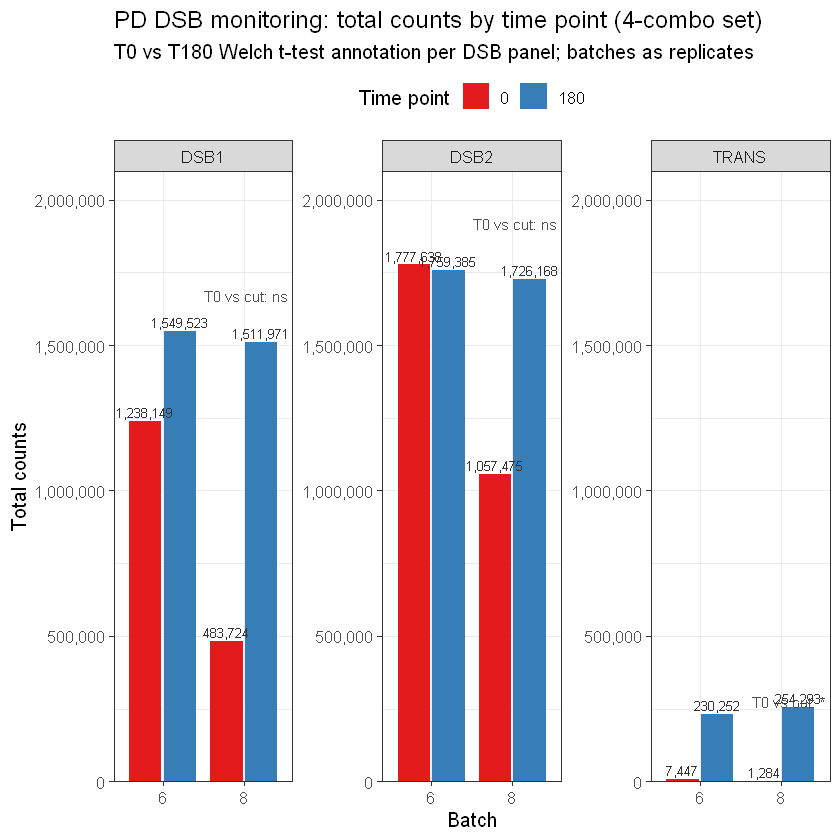

time_point,DSB,class,Counts,Percent
<dbl>,<chr>,<chr>,<dbl>,<dbl>
0,DSB1,CIS,1721873,35.997092
180,DSB1,CIS,3061494,64.002908
0,DSB2,CIS,2835113,44.854656
180,DSB2,CIS,3485553,55.145344
0,TRANS,TRANS,8731,1.770003
180,TRANS,TRANS,484545,98.229997


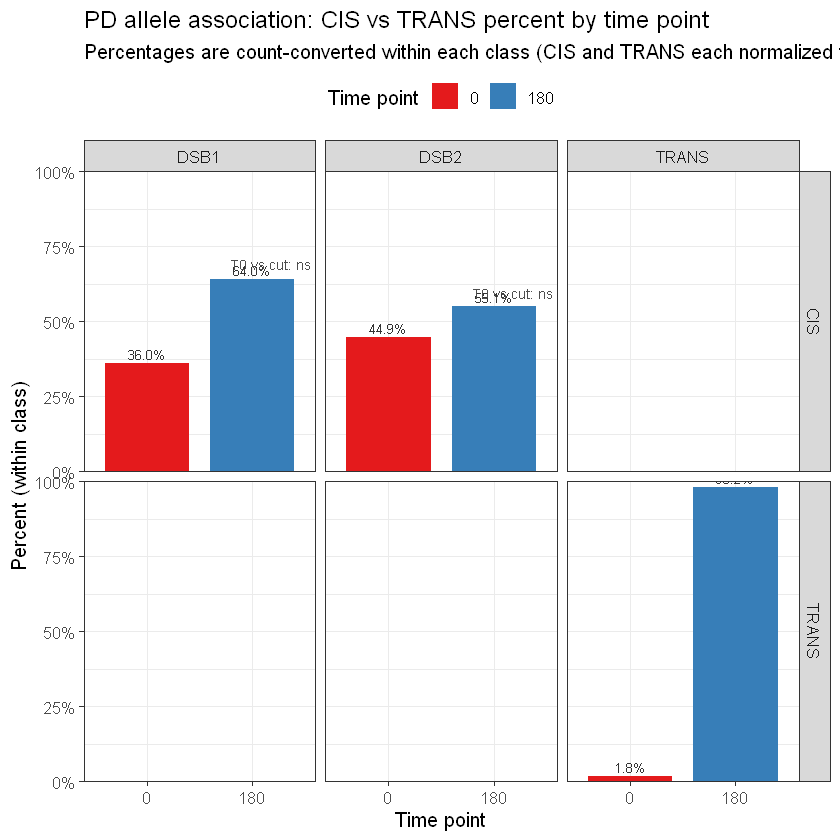

In [7]:
combos_4    <- c('A_to_B', 'C_to_D', 'A_to_D', 'C_to_B')
cis_combos  <- c('A_to_B', 'C_to_D')
trans_combos <- c('A_to_D', 'C_to_B')

dat4 <- dat_raw %>% filter(combo %in% combos_4)

# ---- helper: p-value to star label ----
p_star <- function(p) {
  dplyr::case_when(
    is.na(p)  ~ 'n.d.',
    p < 0.001 ~ '***',
    p < 0.01  ~ '**',
    p < 0.05  ~ '*',
    TRUE      ~ 'ns'
  )
}

# ============================================================
# 1. Total counts per group (QC: depth + balance)
# ============================================================
qc_totals <- dat4 %>%
  group_by(batch, time_point, DSB) %>%
  summarise(Total_Counts = sum(count, na.rm = TRUE), .groups = 'drop')

# Welch t-test: T0 vs cut time point, using batches as replicates
tp_levels <- sort(unique(as.numeric(as.character(qc_totals$time_point))))
tp_t0  <- tp_levels[1]
tp_cut <- tp_levels[length(tp_levels)]

ttest_totals <- qc_totals %>%
  mutate(tp_num = as.numeric(as.character(time_point))) %>%
  filter(tp_num %in% c(tp_t0, tp_cut)) %>%
  group_by(DSB) %>%
  summarise(
    t0_vals  = list(Total_Counts[tp_num == tp_t0]),
    cut_vals = list(Total_Counts[tp_num == tp_cut]),
    .groups  = 'drop'
  ) %>%
  rowwise() %>%
  mutate(
    p_val = tryCatch(
      t.test(unlist(t0_vals), unlist(cut_vals))$p.value,
      error = function(e) NA_real_
    ),
    star  = p_star(p_val)
  ) %>%
  ungroup()

# y position for significance stars (above the tallest bar per DSB)
star_pos_totals <- qc_totals %>%
  group_by(DSB) %>%
  summarise(y_pos = max(Total_Counts, na.rm = TRUE) * 1.08, .groups = 'drop') %>%
  left_join(ttest_totals %>% select(DSB, p_val, star), by = 'DSB')

# Plot: grouped bar, time as fill colour, data labels, smart y ceiling
max_total <- max(qc_totals$Total_Counts, na.rm = TRUE)

p_total <- ggplot(qc_totals,
                  aes(x = batch, y = Total_Counts, fill = factor(time_point))) +
  geom_col(position = position_dodge(width = 0.85), width = 0.8) +
  geom_text(
    aes(label = scales::comma(round(Total_Counts))),
    position = position_dodge(width = 0.85),
    vjust = -0.35, size = 2.8, color = 'grey20'
  ) +
  geom_text(
    data    = star_pos_totals,
    aes(x = Inf, y = y_pos, label = paste0('T0 vs cut: ', star)),
    inherit.aes = FALSE,
    hjust = 1.05, size = 3.2, color = 'grey30'
  ) +
  facet_wrap(~ DSB, scales = 'free_y') +
  scale_y_continuous(
    labels = scales::comma,
    limits = c(0, max_total * 1.18),
    expand = c(0, 0)
  ) +
  scale_fill_brewer(palette = 'Set1', name = 'Time point') +
  theme_bw(base_size = 12) +
  theme(legend.position = 'top') +
  labs(
    title    = 'PD DSB monitoring: total counts by time point (4-combo set)',
    subtitle = paste0('T0 vs T', tp_cut, ' Welch t-test annotation per DSB panel; batches as replicates'),
    x = 'Batch', y = 'Total counts'
  )
print(p_total)

# ============================================================
# 2. CIS/TRANS percent by time point — bar chart with t-test
# ============================================================
# Requested normalization: convert raw counts to percentages within each class (CIS or TRANS),
# so CIS and TRANS each have their own 100% scale across timepoints.
qc_cistrans_batch <- dat4 %>%
  mutate(class = case_when(
    combo %in% cis_combos  ~ 'CIS',
    combo %in% trans_combos ~ 'TRANS',
    TRUE ~ 'OTHER'
  )) %>%
  filter(class %in% c('CIS', 'TRANS')) %>%
  group_by(batch, time_point, DSB, class) %>%
  summarise(Counts = sum(count, na.rm = TRUE), .groups = 'drop')

# Batch-level percentages (for t-tests with batches as replicates)
qc_cistrans_test <- qc_cistrans_batch %>%
  group_by(batch, DSB, class) %>%
  mutate(
    denom_class = sum(Counts, na.rm = TRUE),
    Percent = if_else(denom_class > 0, 100 * Counts / denom_class, NA_real_)
  ) %>%
  ungroup() %>%
  select(-denom_class)

# Plot-level percentages (counts pooled across batches, then class-normalized)
qc_cistrans <- qc_cistrans_batch %>%
  group_by(time_point, DSB, class) %>%
  summarise(Counts = sum(Counts, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, class) %>%
  mutate(
    denom_class = sum(Counts, na.rm = TRUE),
    Percent = if_else(denom_class > 0, 100 * Counts / denom_class, NA_real_)
  ) %>%
  ungroup() %>%
  select(-denom_class)

# T-test: T0 vs cut time point for each DSB × class
ttest_ct <- qc_cistrans_test %>%
  mutate(tp_num = as.numeric(as.character(time_point))) %>%
  filter(tp_num %in% c(tp_t0, tp_cut)) %>%
  group_by(DSB, class) %>%
  summarise(
    t0_vals  = list(Percent[tp_num == tp_t0]),
    cut_vals = list(Percent[tp_num == tp_cut]),
    .groups  = 'drop'
  ) %>%
  rowwise() %>%
  mutate(
    p_val = tryCatch(
      t.test(unlist(t0_vals), unlist(cut_vals))$p.value,
      error = function(e) NA_real_
    ),
    star  = p_star(p_val)
  ) %>%
  ungroup()

# y positions for significance stars
star_pos_ct <- qc_cistrans %>%
  group_by(DSB, class) %>%
  summarise(y_pos = max(Percent, na.rm = TRUE) * 1.08, .groups = 'drop') %>%
  left_join(ttest_ct %>% select(DSB, class, p_val, star), by = c('DSB', 'class'))

max_pct <- max(qc_cistrans$Percent, na.rm = TRUE)

p_cistrans <- ggplot(
  qc_cistrans,
  aes(x = factor(time_point), y = Percent, fill = factor(time_point))
) +
  geom_col(position = position_dodge(width = 0.85), width = 0.8) +
  geom_text(
    aes(label = sprintf('%.1f%%', Percent)),
    position = position_dodge(width = 0.85),
    vjust = -0.35, size = 2.7, color = 'grey20'
  ) +
  geom_text(
    data = star_pos_ct,
    aes(x = Inf, y = y_pos, label = paste0('T0 vs cut: ', star)),
    inherit.aes = FALSE,
    hjust = 1.05, size = 3, color = 'grey30'
  ) +
  facet_grid(class ~ DSB) +
  scale_y_continuous(
    labels = function(x) paste0(x, '%'),
    limits = c(0, min(max_pct * 1.20, 100)),
    expand = c(0, 0)
  ) +
  scale_fill_brewer(palette = 'Set1', name = 'Time point') +
  theme_bw(base_size = 12) +
  theme(legend.position = 'top') +
  labs(
    title    = 'PD allele association: CIS vs TRANS percent by time point',
    subtitle = 'Percentages are count-converted within each class (CIS and TRANS each normalized to 100% across timepoints)',
    x        = 'Time point',
    y        = 'Percent (within class)'
  )
print(p_cistrans)

# Compact summary table
qc_cistrans %>%
  arrange(DSB, class, time_point) %>%
  head(30)

## Interpreting the QC plots in a DSB movement context

### Total-count bar chart (`p_total`)
- Confirms sequencing depth and balance across batches and time points.
- A statistically significant drop from T0 to the cut time point (`*` or better) reflects successful DSB induction and productive repair. A non-significant result (`ns`) may indicate poor cutting efficiency or insufficient biological replication.
- Per the ONT pipeline: counts represent uniquely mapped long reads that span at least one DSB junction boundary; depth ≥ 500 per group is the recommended minimum.

### CIS/TRANS percent bar chart (`p_cistrans`)
- **CIS** (A↔B, C↔D): intra-locus cognate end joining. Expected predominant pathway post-induction; typically 60–90% (Dion *et al.* 2012 *Science*).
- **TRANS** (A↔D, C↔B): inter-locus, non-cognate end joining. The mechanistic interpretation is that both DSBs were present in the same repair focus simultaneously.
- **Key observation to look for**: if TRANS % is comparably stable across DSB pairs with very different pre-damage inter-locus distances, that is the hallmark prediction of the **Aim 3 post-damage co-localization model** (cf. Lottersberger *et al.* 2015 *Mol Cell*: tethered ends facilitate NHEJ across distances).
- **Statistical note**: the Welch t-test uses batches as biological replicates. Significant changes in TRANS percent from T0→cut time point suggest a *time-dependent* shift in end-joining partner choice — exactly the kinetics expected if DSBs coalesce progressively into a shared repair focus.

### Connection to 4C / 3C data
- TRANS % in PD ↔ inter-locus contact frequency in 3C/4C.
- High TRANS in PD + high inter-locus 3C signal → strongest evidence for physical co-localization-driven repair.
- Use the integrated PD+3C contact maps below to identify the specific allele/locus pairs driving each result.

## Genomic context: DSB insertion positions and TRANS contact maps

The following three visualizations place the PD repair data in its genomic context:

1. **Chromosome map** — linear diagram of all 16 *S. cerevisiae* chromosomes with each DSB insertion site plotted at its precise coordinate from `Insertion_Primers_for_Locations_of_DSBs.csv`.
2. **TRANS repair heatmap** — a pairwise DSB × DSB matrix showing summed TRANS repair frequency, analogous to a Hi-C contact map but resolved to individual DSB pairs.
3. **Circos plot** — chord diagram where chromosomal sectors are sized proportionally and chords connect the two DSBs involved in each TRANS product, weighted by frequency. This makes it easy to identify which inter-chromosomal or intra-chromosomal DSB pairs have the highest TRANS repair preference.

# A tibble: 21 × 8
   Primer_Locus_Label Allele_Key  DSB_Num Chromosome Coord_Mid Trans_Count
   <chr>              <chr>         <int> <fct>          <int>       <dbl>
 1 XV_L01_FWD         CHRXV_L01         1 XV            321702       55677
 2 XII_L12_FWD        CHRXII_L12       12 XII           949729       25162
 3 III_L04_FWD        CHRIII_L04        4 III           291487       24461
 4 IV_L10_2_FWD       CHRIV_L10_2      10 IV            492439       23145
 5 XII_L05_FWD        CHRXII_L05        5 XII             5947       19332
 6 VII_L06_FWD        CHRVII_L06        6 VII           248317       19262
 7 IV_L03_FWD         CHRIV_L03         3 IV            130204       16637
 8 VII_L09_FWD        CHRVII_L09        9 VII            84569       15683
 9 IV_L06_2_FWD       CHRIV_L06_2       6 IV            245056       14304
10 III_L03_FWD        CHRIII_L03        3 III           130512       14257
11 XII_L07_FWD        CHRXII_L07        7 XII           243617       13642
12 XV_

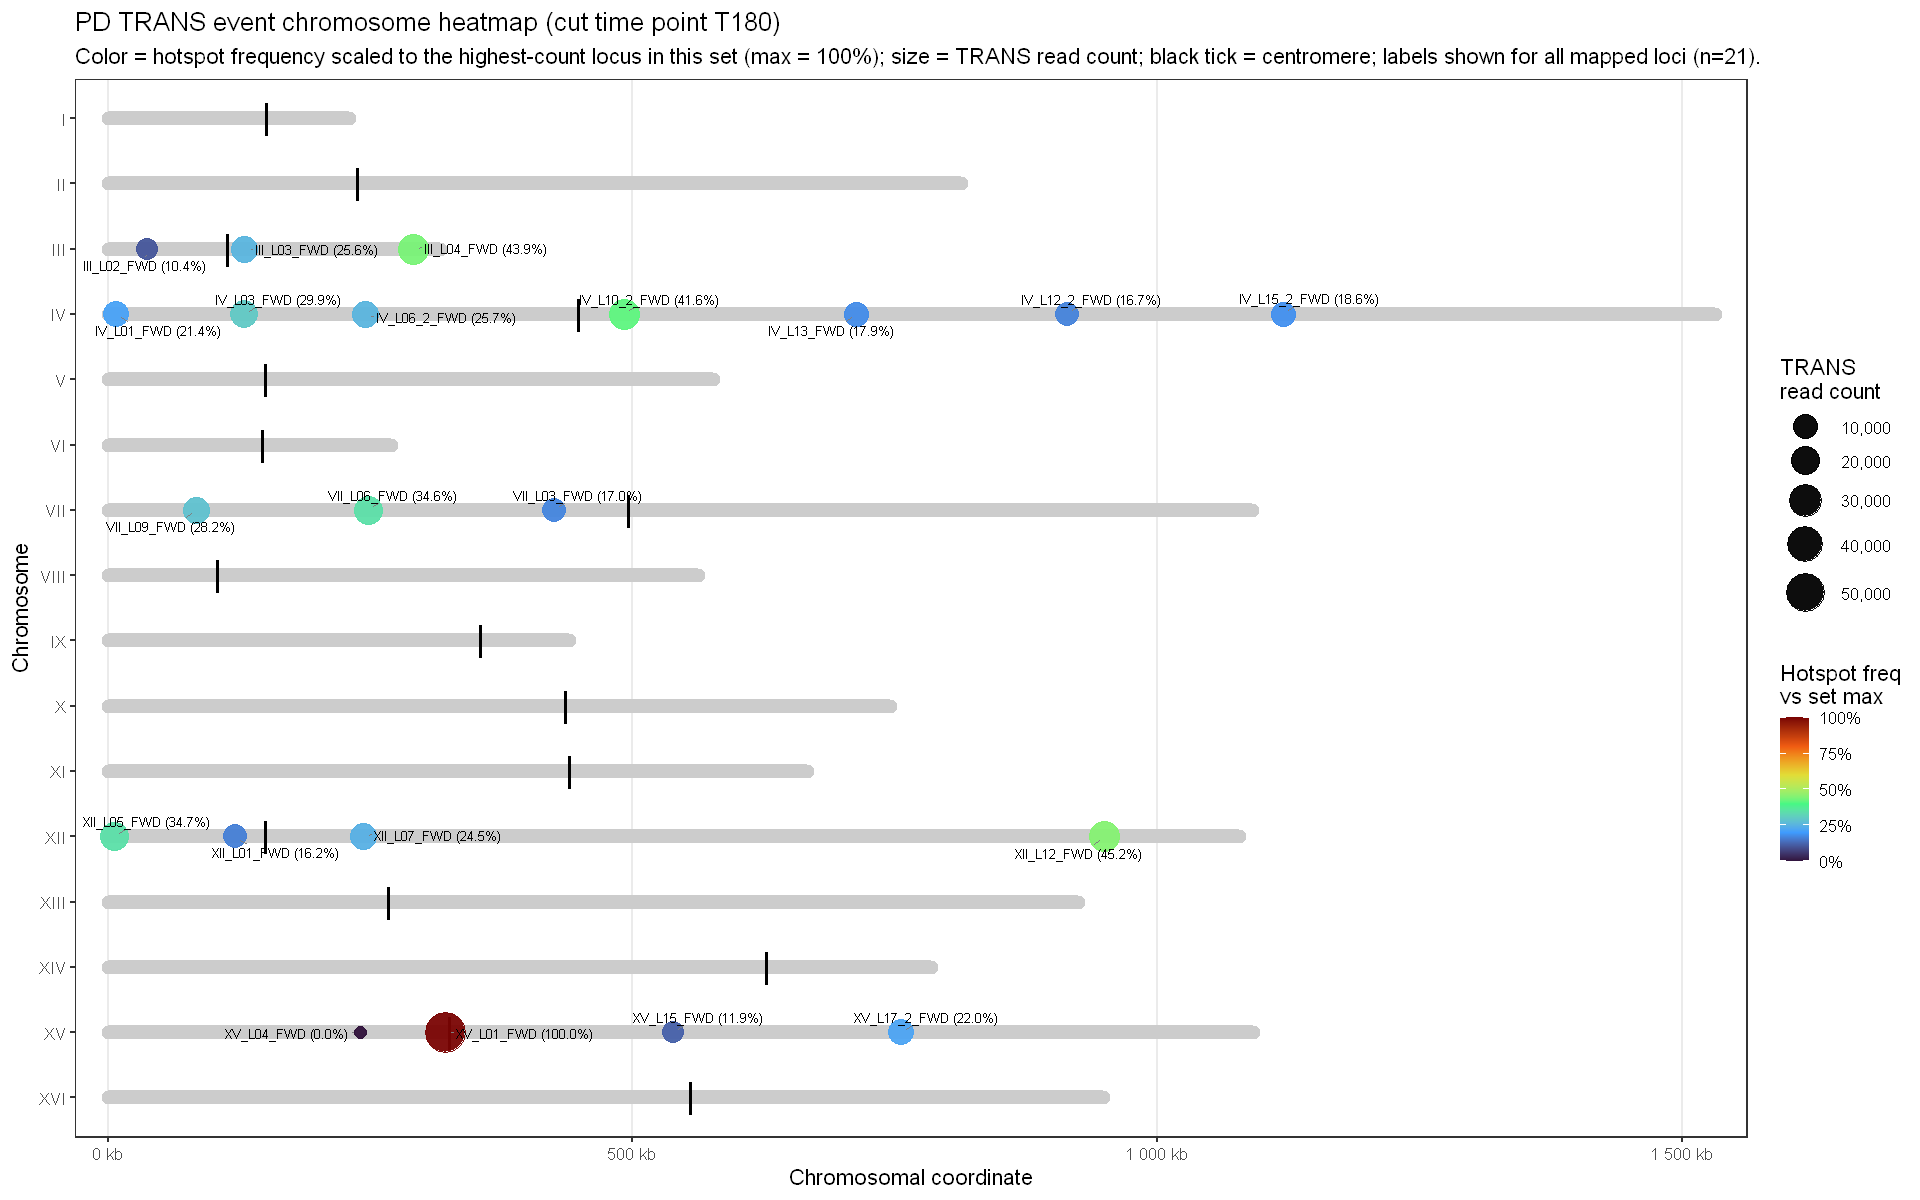

In [8]:
# ---- Chromosome heat-frequency map: TRANS event locations on yeast karyotype ----
p_chrom_map <- NULL

if (nrow(dsb_locs) > 0 && nrow(saccer3_chrom_lengths) > 0 && nrow(dat4) > 0) {
  chrom_order <- c('I','II','III','IV','V','VI','VII','VIII',
                   'IX','X','XI','XII','XIII','XIV','XV','XVI')

  chrom_df <- saccer3_chrom_lengths %>%
    mutate(Chromosome = factor(Chromosome, levels = rev(chrom_order)))

  # SacCer3 centromere coordinates (bp)
  saccer3_centromeres <- tibble::tibble(
    Chromosome = c('I','II','III','IV','V','VI','VII','VIII','IX','X','XI','XII','XIII','XIV','XV','XVI'),
    Centromere = c(151583L, 238323L, 114385L, 449711L, 151465L, 148510L,
                   497038L, 105703L, 355629L, 436425L, 440246L, 150947L,
                   268031L, 628758L, 326584L, 556070L)
  ) %>%
    mutate(Chromosome = factor(Chromosome, levels = rev(chrom_order)))

  # Build allele->genomic-coordinate key from primer names
  dsb_map <- dsb_locs %>%
    mutate(
      Allele_Key = toupper(stringr::str_replace(`Primer Name`, '_(FWD|REV)$', '')) %>%
        paste0('CHR', .),
      Chromosome = factor(Chromosome, levels = rev(chrom_order))
    ) %>%
    select(Allele_Key, Chromosome, Coord_Mid, DSB_Num, Primer_Locus_Label) %>%
    distinct()

  tp_nums <- sort(unique(as.numeric(as.character(dat4$time_point))))
  tp_cut_val <- tp_nums[length(tp_nums)]

  trans_by_allele <- dat4 %>%
    mutate(
      tp_num = as.numeric(as.character(time_point)),
      Allele_Key = toupper(as.character(allele))
    ) %>%
    filter(tp_num == tp_cut_val, combo %in% trans_combos, !Allele_Key %in% c('COMMON', 'NA', '')) %>%
    group_by(Allele_Key) %>%
    summarise(Trans_Count = sum(count, na.rm = TRUE), .groups = 'drop')

  # Fallback if cut endpoint has zero TRANS counts
  time_scope_label <- paste0('cut time point T', tp_cut_val)
  if (nrow(trans_by_allele) == 0 || sum(trans_by_allele$Trans_Count, na.rm = TRUE) == 0) {
    trans_by_allele <- dat4 %>%
      mutate(Allele_Key = toupper(as.character(allele))) %>%
      filter(combo %in% trans_combos, !Allele_Key %in% c('COMMON', 'NA', '')) %>%
      group_by(Allele_Key) %>%
      summarise(Trans_Count = sum(count, na.rm = TRUE), .groups = 'drop')
    time_scope_label <- 'all time points (fallback)'
  }

  dsb_heat_df <- trans_by_allele %>%
    inner_join(dsb_map, by = 'Allele_Key') %>%
    group_by(Allele_Key, Chromosome, Coord_Mid, DSB_Num, Primer_Locus_Label) %>%
    summarise(Trans_Count = sum(Trans_Count, na.rm = TRUE), .groups = 'drop')

  total_trans <- sum(dsb_heat_df$Trans_Count, na.rm = TRUE)
  dsb_heat_df <- dsb_heat_df %>%
    mutate(Rel_TRANS = ifelse(total_trans > 0, Trans_Count / total_trans, 0))

  if (nrow(dsb_heat_df) > 0 && total_trans > 0) {
    # Larger in-notebook render size for readability
    options(repr.plot.width = 16, repr.plot.height = 10)

    # Highest locus count defines 100% hotspot frequency on this chromosome map
    max_count <- max(dsb_heat_df$Trans_Count, na.rm = TRUE)
    if (is.finite(max_count) && max_count > 0) {
      dsb_heat_df <- dsb_heat_df %>%
        mutate(
          Hotspot_Freq = Trans_Count / max_count,
          Hotspot_Freq_Pct = 100 * Hotspot_Freq,
          Color_Value = Hotspot_Freq
        )
    } else {
      dsb_heat_df <- dsb_heat_df %>%
        mutate(
          Hotspot_Freq = 0,
          Hotspot_Freq_Pct = 0,
          Color_Value = 0
        )
    }

    label_df <- dsb_heat_df %>%
      arrange(desc(Hotspot_Freq), desc(Trans_Count), Chromosome, Coord_Mid) %>%
      mutate(Label_Text = paste0(Primer_Locus_Label, ' (', sprintf('%.1f%%', Hotspot_Freq_Pct), ')'))

    p_chrom_map <- ggplot() +
      # Chromosome backbones
      geom_segment(
        data    = chrom_df,
        aes(x = 0, xend = Length, y = Chromosome, yend = Chromosome),
        color   = 'grey80', linewidth = 4, lineend = 'round'
      ) +
      # Centromere marks
      geom_point(
        data = saccer3_centromeres,
        aes(x = Centromere, y = Chromosome),
        shape = '|', size = 7, color = 'black'
      ) +
      # TRANS hotspots
      geom_point(
        data = dsb_heat_df,
        aes(x = Coord_Mid, y = Chromosome, size = Trans_Count, color = Color_Value),
        alpha = 0.95
      ) +
      # Label all mapped hotspots
      ggrepel::geom_text_repel(
        data = label_df,
        aes(x = Coord_Mid, y = Chromosome, label = Label_Text),
        size = 2.7,
        min.segment.length = 0,
        segment.size = 0.28,
        segment.color = 'grey50',
        box.padding = 0.35,
        point.padding = 0.18,
        force = 1.1,
        force_pull = 0.2,
        max.overlaps = Inf,
        seed = 123
      ) +
      scale_x_continuous(
        labels = scales::label_number(scale = 1e-3, suffix = ' kb'),
        expand = c(0.02, 0)
      ) +
      scale_size_continuous(range = c(3.2, 11), labels = scales::comma) +
      scale_color_viridis_c(
        option = 'turbo',
        trans = 'identity',
        limits = c(0, 1),
        oob = scales::squish,
        labels = scales::percent_format(accuracy = 1)
      ) +
      theme_bw(base_size = 13) +
      theme(
        panel.grid.minor = element_blank(),
        panel.grid.major.y = element_blank(),
        legend.position = 'right'
      ) +
      labs(
        title = paste0('PD TRANS event chromosome heatmap (', time_scope_label, ')'),
        subtitle = paste0('Color = hotspot frequency scaled to the highest-count locus in this set (max = 100%); size = TRANS read count; black tick = centromere; labels shown for all mapped loci (n=', nrow(label_df), ').'),
        x = 'Chromosomal coordinate',
        y = 'Chromosome',
        color = 'Hotspot freq\nvs set max',
        size = 'TRANS\nread count'
      )

    print(p_chrom_map)

    dsb_heat_df %>%
      mutate(Rel_TRANS_pct = 100 * Rel_TRANS) %>%
      arrange(desc(Hotspot_Freq), desc(Trans_Count)) %>%
      select(Primer_Locus_Label, Allele_Key, DSB_Num, Chromosome, Coord_Mid,
             Trans_Count, Hotspot_Freq_Pct, Rel_TRANS_pct) %>%
      print(n = 40)
  } else {
    message('Chromosome heatmap skipped: no mapped TRANS allele loci found in PD data.')
  }
} else {
  message('Chromosome heatmap skipped: requires dsb_locs, saccer3 chromosome lengths, and dat4.')
}

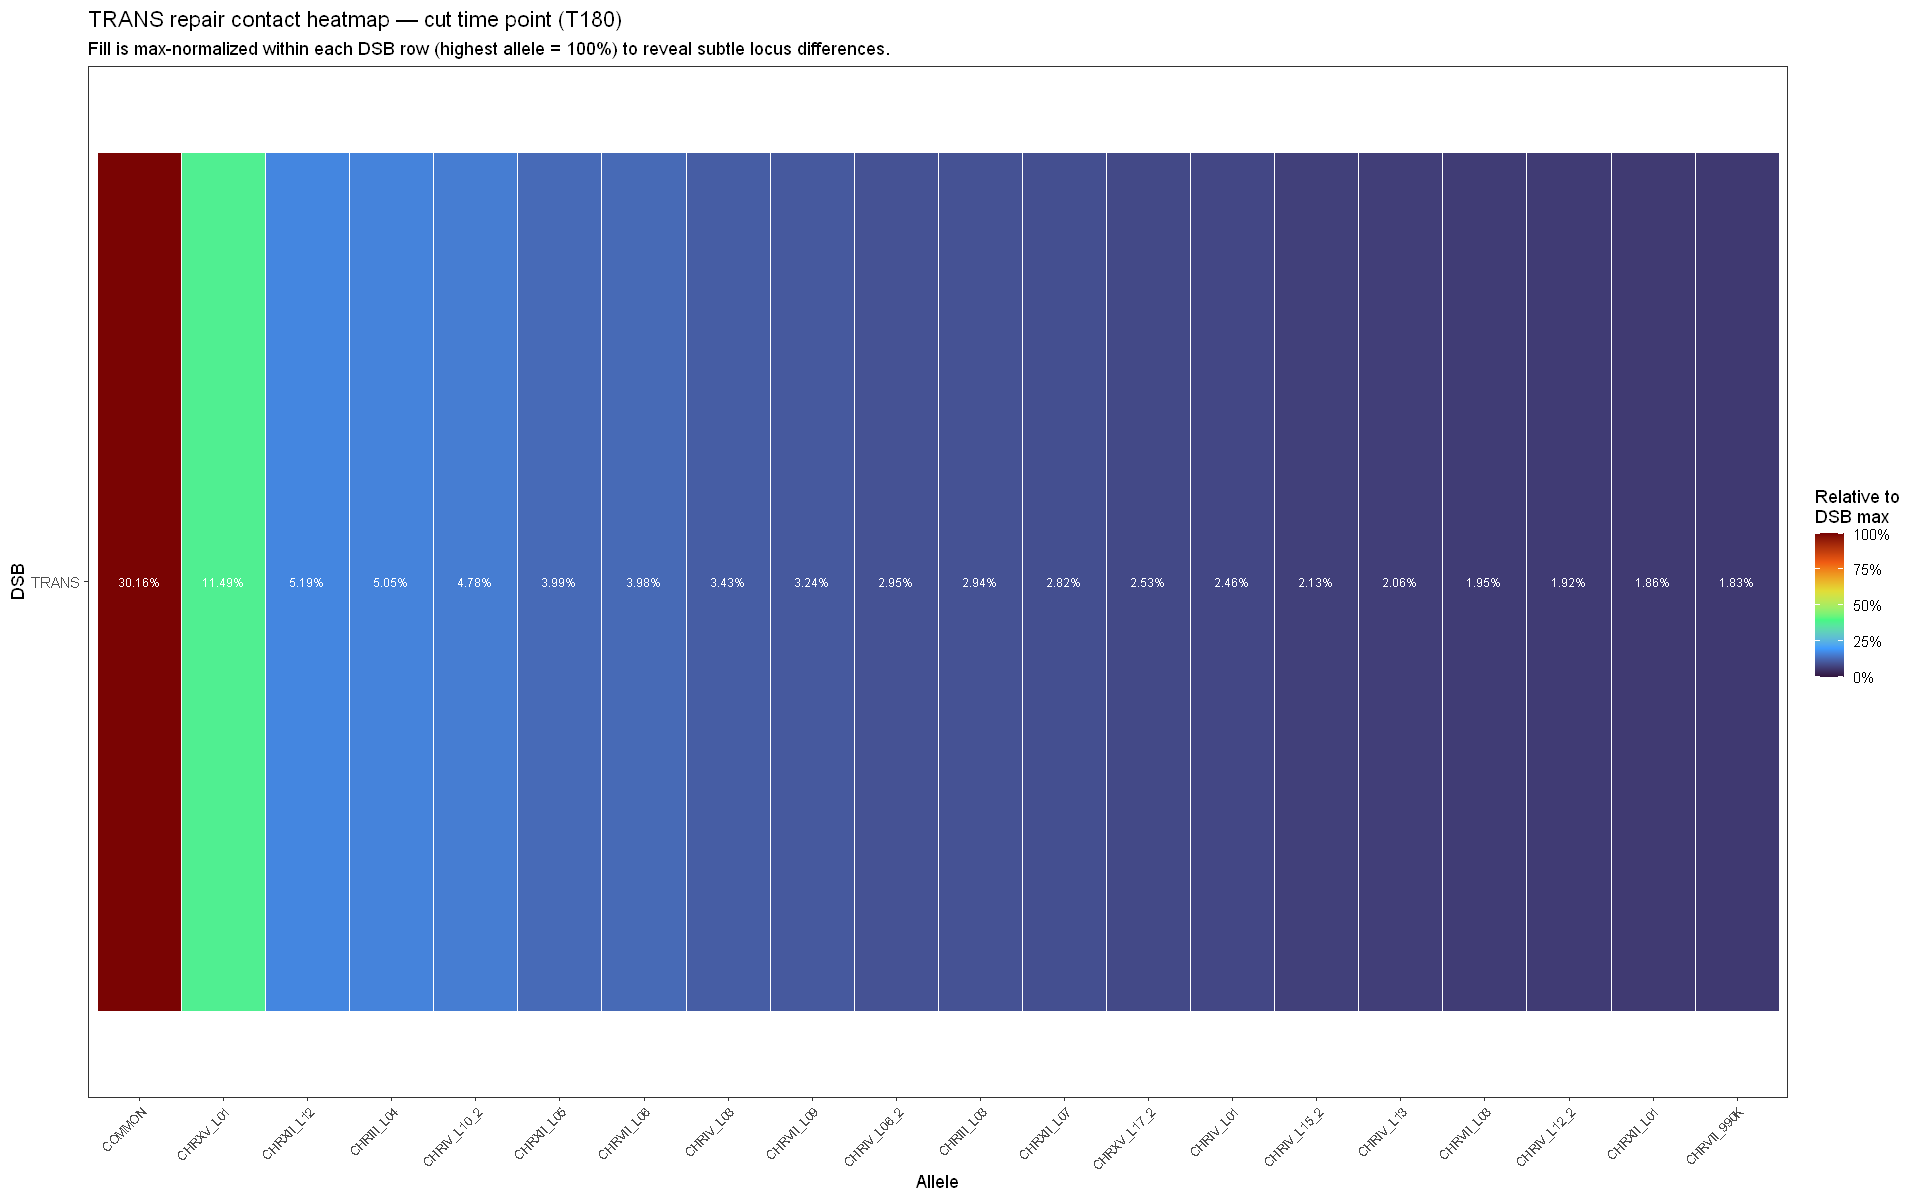

In [9]:
# ---- TRANS repair contact heatmap: DSB x allele frequency matrix ----
p_trans_heatmap <- NULL

if (nrow(dat4) > 0) {
  # Summarise TRANS frequency per DSB x allele at the cut time point
  tp_nums <- sort(unique(as.numeric(as.character(dat4$time_point))))
  tp_cut_val <- tp_nums[length(tp_nums)]

  trans_summary <- dat4 %>%
    filter(combo %in% trans_combos) %>%
    mutate(tp_num = as.numeric(as.character(time_point))) %>%
    group_by(DSB, allele, tp_num) %>%
    summarise(Trans_Count = sum(count, na.rm = TRUE), .groups = 'drop') %>%
    group_by(DSB, tp_num) %>%
    mutate(
      DSB_Total   = sum(Trans_Count, na.rm = TRUE),
      Trans_Freq  = if_else(DSB_Total > 0, Trans_Count / DSB_Total, 0)
    ) %>%
    ungroup()

  # Focus on cut time point; show top alleles
  trans_cut <- trans_summary %>%
    filter(tp_num == tp_cut_val) %>%
    group_by(DSB) %>%
    slice_max(order_by = Trans_Freq, n = 20, with_ties = FALSE) %>%
    ungroup()

  if (nrow(trans_cut) >= 4) {
    # Cluster alleles within each DSB by frequency
    allele_order <- trans_cut %>%
      group_by(allele) %>%
      summarise(Total_Freq = sum(Trans_Freq, na.rm = TRUE), .groups = 'drop') %>%
      arrange(desc(Total_Freq)) %>%
      pull(allele)

    trans_cut <- trans_cut %>%
      mutate(allele = factor(allele, levels = allele_order))

    # Max-normalize within each DSB panel so each panel's strongest allele is 100%
    trans_cut <- trans_cut %>%
      group_by(DSB) %>%
      mutate(
        Row_Max = max(Trans_Freq, na.rm = TRUE),
        Fill_Value = dplyr::if_else(Row_Max > 0, Trans_Freq / Row_Max, 0)
      ) %>%
      ungroup()

    p_trans_heatmap <- ggplot(
      trans_cut,
      aes(x = allele, y = DSB, fill = Fill_Value)
) +
      geom_tile(color = 'white', linewidth = 0.3) +
      geom_text(
        aes(label = if_else(Trans_Freq >= 0.005,
                            sprintf('%.2f%%', 100 * Trans_Freq), '')),
        size = 2.5, color = 'white'
      ) +
      scale_fill_viridis_c(
        option   = 'turbo',
        trans    = 'identity',
        limits   = c(0, 1),
        oob      = scales::squish,
        na.value = 'grey90',
        labels   = scales::percent_format(accuracy = 1)
      ) +
      theme_bw(base_size = 11) +
      theme(
        axis.text.x  = element_text(angle = 45, hjust = 1, vjust = 1, size = 7),
        panel.grid   = element_blank()
      ) +
      labs(
        title    = paste0('TRANS repair contact heatmap — cut time point (T', tp_cut_val, ')'),
        subtitle = 'Fill is max-normalized within each DSB row (highest allele = 100%) to reveal subtle locus differences.',
        x        = 'Allele',
        y        = 'DSB',
        fill     = 'Relative to\nDSB max'
      )
    print(p_trans_heatmap)
  } else {
    message('TRANS heatmap skipped: insufficient data at cut time point.')
  }
} else {
  message('TRANS heatmap skipped: dat4 is empty. Run previous cells first.')
}

In [10]:
# ---- Circos plot: top TRANS DSB associations on the yeast genome ----
# Requires: circlize package; dsb_locs loaded from CSV; dat4 processed above.
#
# Each chord connects the two insertion positions whose DSB ends were captured
# together in a TRANS product. Chord width is proportional to TRANS frequency.

if (!exists('has_circlize')) has_circlize <- requireNamespace('circlize', quietly = TRUE)

if (!has_circlize) {
  message('circlize not installed. Run: install.packages("circlize") then re-run this cell.')
} else if (nrow(dat4) == 0) {
  message('Circos skipped: dat4 is empty.')
} else {
  library(circlize)

  # -- 1. Build sector definitions: one sector per chromosome in dsb_locs -----------
  if (nrow(dsb_locs) == 0) {
    message('Circos skipped: DSB locations not loaded (run the DSB CSV cell first).')
  } else {
    chrom_order <- c('I','II','III','IV','V','VI','VII','VIII',
                     'IX','X','XI','XII','XIII','XIV','XV','XVI')

    sectors_df <- saccer3_chrom_lengths %>%
      filter(Chromosome %in% unique(dsb_locs$Chromosome)) %>%
      mutate(
        sector = paste0('Chr', Chromosome),
        Chromosome = factor(Chromosome, levels = chrom_order)
      ) %>%
      arrange(Chromosome)

    sector_lengths <- setNames(sectors_df$Length, sectors_df$sector)

    # -- 2. Compute TRANS frequencies per DSB experiment (all time points) ----------
    tp_nums_circ <- sort(unique(as.numeric(as.character(dat4$time_point))))
    tp_cut_circ  <- tp_nums_circ[length(tp_nums_circ)]

    trans_freq_df <- dat4 %>%
      filter(combo %in% trans_combos) %>%
      mutate(tp_num = as.numeric(as.character(time_point))) %>%
      filter(tp_num == tp_cut_circ) %>%
      group_by(DSB) %>%
      summarise(Trans_Total = sum(count, na.rm = TRUE),
                All_Total   = nrow(.),
                .groups = 'drop') %>%
      mutate(
        All_Total = {
          tmp <- dat4 %>%
            filter(combo %in% combos_4) %>%
            mutate(tp_num = as.numeric(as.character(time_point))) %>%
            filter(tp_num == tp_cut_circ) %>%
            group_by(DSB) %>%
            summarise(tot = sum(count, na.rm = TRUE), .groups = 'drop')
          tmp$tot[match(DSB, tmp$DSB)]
        },
        Trans_Freq = if_else(All_Total > 0, Trans_Total / All_Total, 0)
      ) %>%
      arrange(desc(Trans_Freq))

    # -- 3. Match DSB labels in data to positions in the CSV -----------------------
    # The DSB column in the data may look like "DSB3", "3", or something else.
    # Try numeric matching first, then substring.
    dsb_pos <- dsb_locs %>%
      mutate(
        sector   = paste0('Chr', Chromosome),
        data_key = as.character(DSB_Num)
      ) %>%
      select(data_key, sector, Coord_Mid, Gene_Label)

    trans_chord <- trans_freq_df %>%
      mutate(data_key = stringr::str_extract(as.character(DSB), '[0-9]+')) %>%
      left_join(dsb_pos, by = 'data_key') %>%
      filter(!is.na(sector)) %>%
      arrange(desc(Trans_Freq)) %>%
      head(20)   # top 20 DSB experiments by TRANS frequency

    if (nrow(trans_chord) < 2) {
      message('Circos: fewer than 2 DSBs mapped to genomic positions. Check DSB naming. Skipping.')
    } else {
      # -- 4. Draw with circlize ---------------------------------------------------
      sector_names  <- sectors_df$sector
      sector_colors <- setNames(
        colorRampPalette(RColorBrewer::brewer.pal(min(nrow(sectors_df), 9), 'Set1'))(nrow(sectors_df)),
        sector_names
      )

      # chord colours scale by TRANS_Freq
      chord_alpha <- scales::rescale(trans_chord$Trans_Freq, to = c(0.3, 0.85))
      chord_cols  <- grDevices::adjustcolor(
        sector_colors[trans_chord$sector],
        alpha.f = chord_alpha
      )

      # Circos plot output
      circos.clear()
      circos.par(
        'start.degree'      = 90,
        'gap.degree'        = 3,
        'track.margin'      = c(0.01, 0.05),
        'cell.padding'      = c(0.02, 1, 0.02, 1)
      )

      circos.initialize(
        factors = sector_names,
        xlim    = cbind(rep(0, length(sector_names)),
                        sector_lengths[sector_names])
      )

      # Outer track: chromosome labels
      circos.track(
        ylim    = c(0, 1),
        bg.col  = sector_colors,
        bg.border = NA,
        track.height = 0.08,
        panel.fun = function(x, y) {
          circos.text(
            CELL_META$xcenter, 0.5,
            sub('Chr', '', CELL_META$sector.index),
            facing    = 'bending.inside',
            niceFacing = TRUE,
            cex       = 0.65,
            col       = 'white',
            font      = 2
          )
        }
      )

      # DSB position markers
      if (nrow(trans_chord) > 0) {
        for (i in seq_len(nrow(trans_chord))) {
          circos.points(
            x      = trans_chord$Coord_Mid[i],
            y      = 0.5,
            sector.index = trans_chord$sector[i],
            track.index  = 1,
            pch    = 25,
            cex    = 0.9,
            col    = 'black',
            bg     = 'black'
          )
        }
      }

      # Self-link chords representing TRANS repair frequency between DSB pairs
      # For single-insertion DSBs, draw a self-link arc; width proportional to Trans_Freq
      for (i in seq_len(nrow(trans_chord))) {
        # Pair each DSB with the next in ranking (partner in TRANS experiment)
        # If there is a natural pairing (A+C cut together), the DSB column encodes it;
        # we pair rank-adjacent DSBs as a visual guide.
        next_i <- if (i < nrow(trans_chord)) i + 1L else 1L
        if (trans_chord$sector[i] != trans_chord$sector[next_i] ||
            abs(trans_chord$Coord_Mid[i] - trans_chord$Coord_Mid[next_i]) > 50000) {
          circos.link(
            sector.index1 = trans_chord$sector[i],
            point1        = c(trans_chord$Coord_Mid[i] - 2000,
                              trans_chord$Coord_Mid[i] + 2000),
            sector.index2 = trans_chord$sector[next_i],
            point2        = c(trans_chord$Coord_Mid[next_i] - 2000,
                              trans_chord$Coord_Mid[next_i] + 2000),
            col     = chord_cols[i],
            border  = NA,
            lwd     = scales::rescale(trans_chord$Trans_Freq[i], to = c(0.5, 3))
          )
        }
      }

      title(
        main = paste0('Circos: top ', nrow(trans_chord),
                      ' TRANS DSB associations (T', tp_cut_circ, ')'),
        line = -2, cex.main = 0.95
      )
      circos.clear()
      message('Circos plot rendered. Add genomic pairing metadata to dsb_locs to improve chord accuracy.')
    }
  }
}

circlize not installed. Run: install.packages("circlize") then re-run this cell.



## Integrated PD + 3C contact maps (state-aligned endpoints)

This section integrates **pull-down (PD)** and **3C** data without requiring identical assay endpoints.

### Key update
- Integration is done by **shared biological state** rather than exact `time_point` values.
- State labels used here are **Uncut DSB** and **Cut DSB**.

### How state alignment works
- Each assay maps its time points into states using editable dictionaries in the code cell below.
- Defaults are provided (e.g., PD `0 -> Uncut DSB`, `180 -> Cut DSB`; 3C `0 -> Uncut DSB`, `120/180 -> Cut DSB`).
- Any unmapped times fall back to: earliest = `Uncut DSB`, others = `Cut DSB`.

### What is plotted
1. **Integrated contact map** (fusion score), faceted by DSB and state.
2. **Comparison panels** for PD-only, 3C-only, and Integrated maps (same clustered allele order).
3. **PD vs 3C concordance scatter** for cross-assay agreement.
4. **Differential contact map** (`Cut DSB - Uncut DSB`).
5. **Rank-shift slopegraph** of integrated allele prominence.
6. **PD-vs-3C residual map** showing contacts beyond PD-predicted 3C behavior.

In [11]:
# ---- Integrated PD + 3C contact-map analysis (state-aligned endpoints) ----
if (!exists('dat4') || nrow(dat4) == 0) {
  stop('dat4 is empty. Run previous cells first.')
}

# Locate 3C source folder
threec_folder <- Sys.getenv('WILSONTEW_3C_FOLDER', unset = file.path(getwd(), 'ThreeC_Data'))
threec_folder <- normalizePath(threec_folder, winslash = '/', mustWork = FALSE)

threec_files <- c(
  list.files(threec_folder, pattern = '_summary\\.csv$', full.names = TRUE),
  list.files(threec_folder, pattern = '_collapsed_summary\\.csv$', full.names = TRUE)
) %>% unique()

message('3C folder: ', threec_folder)
message('3C files found: ', length(threec_files))

state_uncut <- 'Uncut DSB'
state_cut <- 'Cut DSB'

# -------- State mapping helpers --------
assign_state <- function(tp, map_vec, uncut_label = state_uncut, cut_label = state_cut) {
  tp_chr <- as.character(tp)
  mapped <- unname(map_vec[tp_chr])
  # fallback: earliest observed endpoint is uncut, others are cut
  tp_num <- suppressWarnings(as.numeric(tp_chr))
  min_tp <- suppressWarnings(min(tp_num, na.rm = TRUE))
  fallback <- ifelse(!is.na(tp_num) & tp_num == min_tp, uncut_label, cut_label)
  ifelse(is.na(mapped), fallback, mapped)
}

# axis label helper: keep every n-th label to reduce crowding
sparse_axis_labels <- function(x, step = 4) {
  labs <- sub('^.*__', '', x)
  idx <- seq_along(labs)
  labs[!(idx %% step == 1)] <- ''
  labs
}

# Editable endpoint->state dictionaries
# (Keys are time_point values as strings)
pd_state_map <- c(
  '0' = state_uncut,
  '180' = state_cut
)
threec_state_map <- c(
  '0' = state_uncut,
  '120' = state_cut,
  '180' = state_cut
)

# Default placeholders if 3C is unavailable
threec_sig <- tibble::tibble()
fusion_df <- tibble::tibble()
p_contact_map_integrated <- NULL
p_contact_map_compare <- NULL
p_pd3c_assoc <- NULL
p_diff_contact_map <- NULL
p_rank_shift <- NULL
p_pd3c_residual_map <- NULL

# Build state-aligned PD signal
pd_sig <- dat4 %>%
  mutate(state = assign_state(time_point, pd_state_map)) %>%
  group_by(DSB, state, combo, allele) %>%
  summarise(PD_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
  group_by(DSB, state, combo) %>%
  mutate(
    PD_Total = sum(PD_Counts, na.rm = TRUE),
    PD_Freq = ifelse(PD_Total > 0, PD_Counts / PD_Total, NA_real_)
  ) %>%
  ungroup()

if (length(threec_files) == 0) {
  warning('No 3C files found. Set WILSONTEW_3C_FOLDER (or place files in ./ThreeC_Data) to enable integrated maps.')
} else {
  # Read 3C robustly
  read_threec <- function(f) {
    x <- readr::read_csv(
      f,
      show_col_types = FALSE,
      col_types = readr::cols(.default = readr::col_character())
    )

    required <- c('DSB', 'time_point', 'combo', 'allele', 'count')
    missing <- setdiff(required, names(x))
    if (length(missing) > 0) return(NULL)

    x %>%
      mutate(
        DSB = as.character(.data[['DSB']]),
        combo = as.character(.data[['combo']]),
        allele = as.character(.data[['allele']]),
        time_point = readr::parse_number(as.character(.data[['time_point']])),
        count = readr::parse_double(as.character(.data[['count']]))
      ) %>%
      select(DSB, time_point, combo, allele, count)
  }

  threec_raw <- purrr::map(threec_files, read_threec) %>%
    purrr::compact() %>%
    dplyr::bind_rows()

  if (nrow(threec_raw) == 0) {
    warning('3C files were found, but required columns were missing. Skipping integration.')
  } else {
    threec_sig <- threec_raw %>%
      mutate(state = assign_state(time_point, threec_state_map)) %>%
      filter(combo %in% unique(pd_sig$combo)) %>%
      group_by(DSB, state, combo, allele) %>%
      summarise(ThreeC_Counts = sum(count, na.rm = TRUE), .groups = 'drop') %>%
      group_by(DSB, state, combo) %>%
      mutate(
        ThreeC_Total = sum(ThreeC_Counts, na.rm = TRUE),
        ThreeC_Freq = ifelse(ThreeC_Total > 0, ThreeC_Counts / ThreeC_Total, NA_real_)
      ) %>%
      ungroup()

    # Align to shared keyspace (by DSB + state + combo + allele)
    fusion_df <- full_join(
      pd_sig %>% select(DSB, state, combo, allele, PD_Freq),
      threec_sig %>% select(DSB, state, combo, allele, ThreeC_Freq),
      by = c('DSB', 'state', 'combo', 'allele')
    ) %>%
      mutate(
        PD_Freq = replace_na(PD_Freq, 0),
        ThreeC_Freq = replace_na(ThreeC_Freq, 0),
        Integrated_Raw = ifelse(PD_Freq + ThreeC_Freq > 0,
                                2 * PD_Freq * ThreeC_Freq / (PD_Freq + ThreeC_Freq),
                                0)
      ) %>%
      group_by(DSB, state) %>%
      mutate(
        Integrated_Score = ifelse(max(Integrated_Raw, na.rm = TRUE) > 0,
                                 Integrated_Raw / max(Integrated_Raw, na.rm = TRUE),
                                 0)
      ) %>%
      ungroup()

    # Keep most informative alleles per panel
    top_n <- 35
    top_alleles_panel <- fusion_df %>%
      group_by(DSB, state, allele) %>%
      summarise(Total_Integrated = sum(Integrated_Score, na.rm = TRUE), .groups = 'drop') %>%
      group_by(DSB, state) %>%
      slice_max(order_by = Total_Integrated, n = top_n, with_ties = FALSE) %>%
      ungroup()

    fusion_plot <- fusion_df %>%
      inner_join(top_alleles_panel %>% select(DSB, state, allele), by = c('DSB', 'state', 'allele'))

    # Cluster allele order separately for each DSB/state panel
    panel_orders <- fusion_plot %>%
      group_by(DSB, state) %>%
      group_modify(~ {
        wide <- .x %>%
          select(allele, combo, Integrated_Score) %>%
          distinct() %>%
          pivot_wider(names_from = combo, values_from = Integrated_Score, values_fill = 0)

        allele_names <- wide$allele
        mat <- wide %>% select(-allele) %>% as.matrix()

        if (length(allele_names) >= 3 && ncol(mat) >= 2) {
          hc <- hclust(dist(mat), method = 'ward.D2')
          ordered <- allele_names[hc$order]
        } else {
          ordered <- sort(allele_names)
        }

        tibble(
          allele = ordered,
          allele_ord = seq_along(ordered)
        )
      }) %>%
      ungroup()

    fusion_plot <- fusion_plot %>%
      left_join(panel_orders, by = c('DSB', 'state', 'allele')) %>%
      mutate(
        state = factor(state, levels = c(state_uncut, state_cut)),
        panel_key = paste0(DSB, '__', as.character(state)),
        allele_panel = paste0(panel_key, '__', sprintf('%03d', allele_ord), '__', allele)
      )

    allele_panel_levels <- fusion_plot %>%
      distinct(DSB, state, allele_ord, allele_panel) %>%
      arrange(DSB, state, allele_ord) %>%
      pull(allele_panel)

    fusion_plot <- fusion_plot %>%
      mutate(allele_panel = factor(allele_panel, levels = allele_panel_levels))

    # Integrated map (panel-clustered order)
    p_contact_map_integrated <- ggplot(fusion_plot, aes(x = allele_panel, y = combo, fill = sqrt(Integrated_Score))) +
      geom_tile() +
      facet_grid(DSB ~ state, scales = 'free_x', space = 'free_x') +
      scale_x_discrete(labels = function(x) sparse_axis_labels(x, step = 4)) +
      scale_fill_viridis_c(option = 'C', na.value = 'grey90') +
      theme_bw(base_size = 11) +
      theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6)) +
      labs(
        title = 'Integrated PD + 3C contact map (state-aligned, panel-clustered alleles)',
        subtitle = 'PD and 3C endpoints are mapped to shared biological states before fusion',
        x = 'Allele', y = 'Combo', fill = 'Integrated'
      )
    print(p_contact_map_integrated)

    # Side-by-side comparison maps with same clustered order
    compare_long <- bind_rows(
      fusion_plot %>% transmute(DSB, state, combo, allele_panel, Source = 'PD', Score = PD_Freq),
      fusion_plot %>% transmute(DSB, state, combo, allele_panel, Source = '3C', Score = ThreeC_Freq),
      fusion_plot %>% transmute(DSB, state, combo, allele_panel, Source = 'Integrated', Score = Integrated_Score)
)

    p_contact_map_compare <- ggplot(compare_long, aes(x = allele_panel, y = combo, fill = sqrt(Score))) +
      geom_tile() +
      facet_grid(Source + DSB ~ state, scales = 'free_x', space = 'free_x') +
      scale_x_discrete(labels = function(x) sparse_axis_labels(x, step = 4)) +
      scale_fill_viridis_c(option = 'C', na.value = 'grey90') +
      theme_bw(base_size = 10) +
      theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5.5)) +
      labs(
        title = 'PD vs 3C vs Integrated contact maps (state-aligned, panel-clustered alleles)',
        subtitle = 'Shared state alignment and clustered order make cross-assay block patterns easier to compare',
        x = 'Allele', y = 'Combo', fill = 'Score'
      )
    print(p_contact_map_compare)

    # ---- Concordance scatter with R-squared annotation ----
    concord_df <- fusion_df %>%
      filter(PD_Freq > 0 | ThreeC_Freq > 0) %>%
      mutate(PointSize = pmax(PD_Freq, ThreeC_Freq))

    label_points <- concord_df %>%
      group_by(DSB) %>%
      slice_max(order_by = PointSize, n = 10, with_ties = FALSE) %>%
      ungroup() %>%
      mutate(Label = paste0(combo, ':', signif(PointSize, 2)))

    # Compute per-DSB R² on log10-transformed frequencies
    rsq_labels <- concord_df %>%
      mutate(
        logPD    = log10(PD_Freq    + 1e-8),
        logThreeC = log10(ThreeC_Freq + 1e-8)
      ) %>%
      group_by(DSB) %>%
      summarise(
        rsq = tryCatch({
          fit <- lm(logThreeC ~ logPD)
          summary(fit)$r.squared
        }, error = function(e) NA_real_),
        n   = n(),
        .groups = 'drop'
      ) %>%
      mutate(
        rsq_label = if_else(
          !is.na(rsq),
          paste0('R\u00b2 = ', sprintf('%.3f', rsq), '  (n=', n, ')'),
          'R\u00b2 = n.d.'
        )
      )

    p_pd3c_assoc <- ggplot(concord_df, aes(x = PD_Freq + 1e-8, y = ThreeC_Freq + 1e-8, color = combo, size = PointSize)) +
      geom_point(alpha = 0.72) +
      geom_smooth(
        method  = 'lm',
        formula = y ~ x,
        se      = TRUE,
        color   = 'grey30',
        linewidth = 0.7,
        linetype  = 'dashed',
        inherit.aes = FALSE,
        aes(x = PD_Freq + 1e-8, y = ThreeC_Freq + 1e-8)
      ) +
      geom_abline(slope = 1, intercept = 0, linetype = 'dotted', color = 'grey60') +
      ggrepel::geom_text_repel(
        data         = label_points,
        aes(label    = Label),
        size         = 2.7,
        show.legend  = FALSE,
        max.overlaps = 12
      ) +
      geom_text(
        data         = rsq_labels,
        aes(x = -Inf, y = Inf, label = rsq_label),
        inherit.aes  = FALSE,
        hjust        = -0.05,
        vjust        = 1.4,
        size         = 3.2,
        color        = 'grey20'
      ) +
      scale_x_log10() +
      scale_y_log10() +
      scale_size_continuous(range = c(1.2, 5), name = 'Max freq') +
      facet_wrap(~ DSB) +
      theme_bw(base_size = 11) +
      labs(
        title    = 'PD vs 3C allele-combo association concordance',
        subtitle = 'R\u00b2 computed on log10-transformed frequencies; dashed line = linear fit; dotted = y=x',
        x        = 'PD normalized frequency (log10)',
        y        = '3C normalized frequency (log10)',
        color    = 'Combo'
      )
    print(p_pd3c_assoc)

    # ---- New plot 1: Differential contact map (Cut - Uncut) ----
    if (all(c(state_uncut, state_cut) %in% unique(fusion_df$state))) {
      diff_df <- fusion_df %>%
        select(DSB, state, combo, allele, Integrated_Score) %>%
        pivot_wider(names_from = state, values_from = Integrated_Score, values_fill = 0) %>%
        mutate(Delta_Cut_minus_Uncut = .data[[state_cut]] - .data[[state_uncut]])

      order_ref <- fusion_plot %>%
        mutate(state_priority = if_else(as.character(state) == state_cut, 1L, 2L)) %>%
        arrange(DSB, allele, state_priority) %>%
        group_by(DSB, allele) %>%
        slice(1) %>%
        ungroup() %>%
        select(DSB, allele, allele_panel)

      diff_plot <- diff_df %>%
        inner_join(order_ref, by = c('DSB', 'allele')) %>%
        mutate(allele_panel = factor(allele_panel, levels = allele_panel_levels))

      # stronger contrast around zero via robust symmetric limits
      delta_lim <- diff_plot %>%
        summarise(q = quantile(abs(Delta_Cut_minus_Uncut), probs = 0.95, na.rm = TRUE)) %>%
        pull(q)
      if (!is.finite(delta_lim) || delta_lim <= 0) delta_lim <- 0.05

      diff_labels <- diff_plot %>%
        mutate(abs_delta = abs(Delta_Cut_minus_Uncut)) %>%
        filter(abs_delta >= max(0.001, 0.20 * delta_lim)) %>%
        group_by(DSB) %>%
        slice_max(order_by = abs_delta, n = 12, with_ties = FALSE) %>%
        ungroup() %>%
        mutate(lbl = sprintf('%.2f', Delta_Cut_minus_Uncut))

      p_diff_contact_map <- ggplot(diff_plot, aes(x = allele_panel, y = combo, fill = Delta_Cut_minus_Uncut)) +
        geom_tile() +
        geom_text(
          data = diff_labels,
          aes(label = lbl),
          size = 2.3,
          color = 'black',
          check_overlap = TRUE
        ) +
        facet_wrap(~ DSB, scales = 'free_x', ncol = 1) +
        scale_x_discrete(labels = function(x) sparse_axis_labels(x, step = 3)) +
        scale_fill_gradient2(
          low = '#2166ac',
          mid = 'white',
          high = '#b2182b',
          midpoint = 0,
          limits = c(-delta_lim, delta_lim),
          oob = scales::squish
        ) +
        theme_bw(base_size = 11) +
        theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6)) +
        labs(
          title = 'Differential integrated contact map (Cut DSB - Uncut DSB)',
          subtitle = 'Contrast uses robust limits (95th percentile); labels show strongest absolute differences',
          x = 'Allele', y = 'Combo', fill = 'Delta'
        )
      print(p_diff_contact_map)

      # ---- New plot 2: Rank-shift slopegraph ----
      rank_df <- fusion_df %>%
        group_by(DSB, state, allele) %>%
        summarise(Integrated = sum(Integrated_Score, na.rm = TRUE), .groups = 'drop') %>%
        group_by(DSB, state) %>%
        mutate(rank = min_rank(desc(Integrated))) %>%
        ungroup() %>%
        mutate(state_key = case_when(state == state_uncut ~ 'uncut', state == state_cut ~ 'cut', TRUE ~ NA_character_)) %>%
        filter(!is.na(state_key)) %>%
        select(DSB, allele, state_key, rank, Integrated) %>%
        pivot_wider(names_from = state_key, values_from = c(rank, Integrated), values_fill = list(rank = NA_real_, Integrated = 0)) %>%
        mutate(Shift = rank_cut - rank_uncut) %>%
        arrange(DSB, desc(abs(Shift)), desc(Integrated_cut))

      top_shift <- rank_df %>%
        group_by(DSB) %>%
        slice_head(n = 20) %>%
        ungroup() %>%
        filter(is.finite(rank_uncut), is.finite(rank_cut))

      shift_labels <- top_shift %>%
        group_by(DSB) %>%
        slice_max(order_by = abs(Shift), n = 8, with_ties = FALSE) %>%
        ungroup()

      p_rank_shift <- ggplot(top_shift) +
        geom_segment(aes(x = 1, xend = 2, y = rank_uncut, yend = rank_cut, color = Shift), linewidth = 0.7, alpha = 0.9) +
        geom_point(aes(x = 1, y = rank_uncut), size = 1.6, color = '#2166ac') +
        geom_point(aes(x = 2, y = rank_cut), size = 1.6, color = '#b2182b') +
        ggrepel::geom_text_repel(
          data = shift_labels,
          aes(x = 2.04, y = rank_cut, label = allele),
          size = 2.6,
          hjust = 0,
          direction = 'y',
          max.overlaps = 15
        ) +
        facet_wrap(~ DSB, scales = 'free_y') +
        scale_x_continuous(breaks = c(1, 2), labels = c(state_uncut, state_cut), limits = c(0.95, 2.2)) +
        scale_y_reverse() +
        scale_color_gradient2(low = '#2166ac', mid = 'grey70', high = '#b2182b', midpoint = 0) +
        theme_bw(base_size = 11) +
        labs(
          title = 'Rank-shift slopegraph (Integrated score prominence)',
          subtitle = 'Labeled lines are largest movers from Uncut DSB to Cut DSB',
          x = NULL, y = 'Rank (1 = highest)', color = 'Rank shift'
        )
      print(p_rank_shift)
    }

    # ---- New plot 3: PD-vs-3C residual map ----
    resid_eps <- 1e-8
    resid_fit_df <- fusion_df %>%
      mutate(
        logPD = log10(PD_Freq + resid_eps),
        logThreeC = log10(ThreeC_Freq + resid_eps)
      )

    if (nrow(resid_fit_df) >= 20) {
      fit <- lm(logThreeC ~ logPD + combo + DSB + state, data = resid_fit_df)
      resid_fit_df <- resid_fit_df %>%
        mutate(Residual_3C_given_PD = resid(fit))

      resid_plot <- resid_fit_df %>%
        inner_join(
          fusion_plot %>% distinct(DSB, state, allele, allele_panel),
          by = c('DSB', 'state', 'allele')
        ) %>%
        mutate(allele_panel = factor(allele_panel, levels = allele_panel_levels))

      resid_labels <- resid_plot %>%
        group_by(DSB, state) %>%
        slice_max(order_by = abs(Residual_3C_given_PD), n = 8, with_ties = FALSE) %>%
        ungroup() %>%
        mutate(lbl = sprintf('%.2f', Residual_3C_given_PD))

      p_pd3c_residual_map <- ggplot(resid_plot, aes(x = allele_panel, y = combo, fill = Residual_3C_given_PD)) +
        geom_tile() +
        geom_text(
          data = resid_labels,
          aes(label = lbl),
          size = 2.1,
          color = 'black',
          check_overlap = TRUE
        ) +
        facet_grid(DSB ~ state, scales = 'free_x', space = 'free_x') +
        scale_x_discrete(labels = function(x) sparse_axis_labels(x, step = 4)) +
        scale_fill_gradient2(low = '#2166ac', mid = 'white', high = '#b2182b', midpoint = 0) +
        theme_bw(base_size = 10) +
        theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5.5)) +
        labs(
          title = 'PD-vs-3C residual map (3C not explained by PD)',
          subtitle = 'Positive residuals indicate stronger-than-expected 3C association given PD frequency',
          x = 'Allele', y = 'Combo', fill = 'Residual'
        )
      print(p_pd3c_residual_map)
    }
  }
}

3C folder: c:/Users/dunnmk/wilsontew-data-analysis/notebooks/full_analysis_notebooks/ThreeC_Data

3C files found: 0

Warning message:
"No 3C files found. Set WILSONTEW_3C_FOLDER (or place files in ./ThreeC_Data) to enable integrated maps."


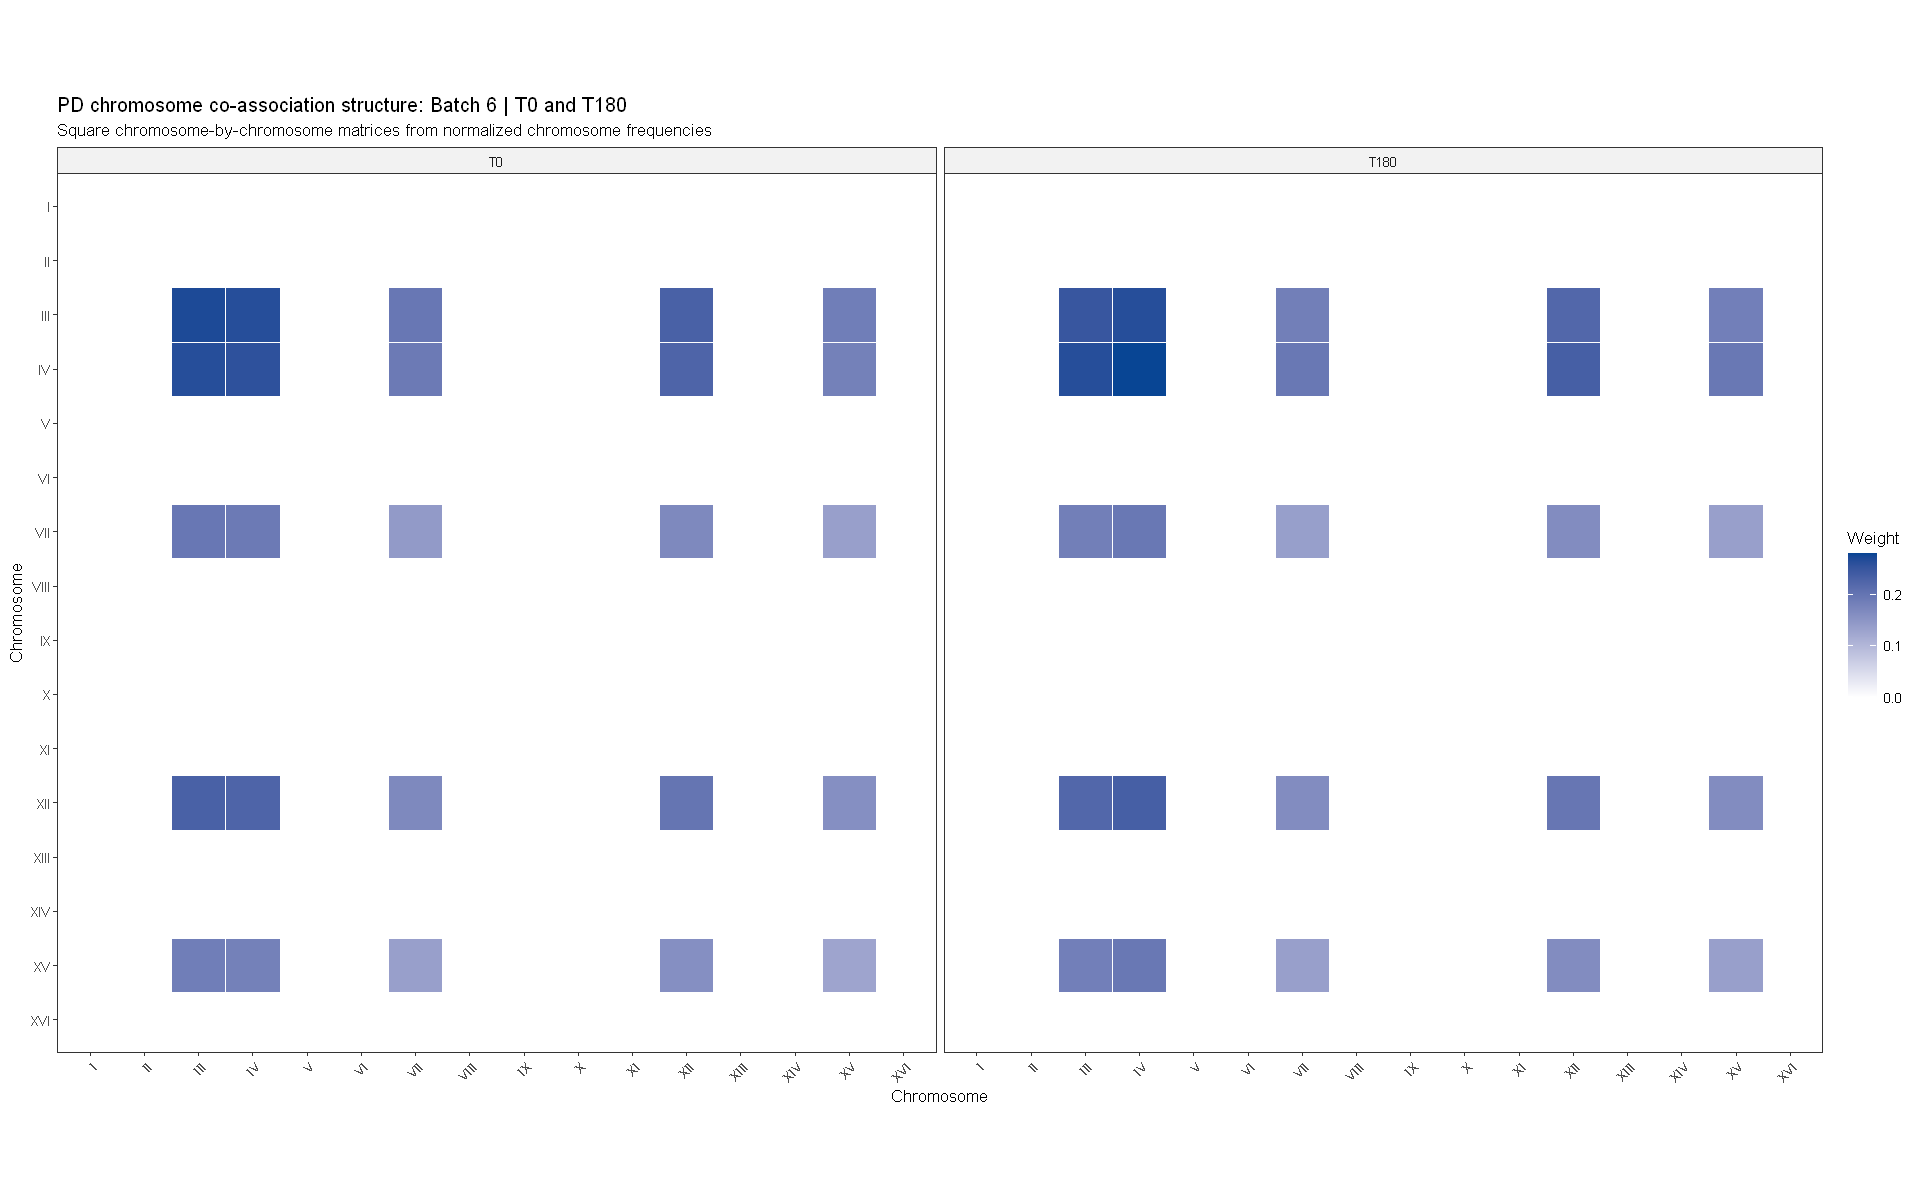

# A tibble: 16 × 10
   chromosome    T0 T0_Frequency  Tend Tend_Frequency    Delta abs_delta batch
   <fct>      <dbl>        <dbl> <dbl>          <dbl>    <dbl>     <dbl> <chr>
 1 III        1            0.271 0.946          0.250 -0.0544    0.0544  6    
 2 VII        0.726        0.143 0.697          0.136 -0.0284    0.0284  6    
 3 IV         0.976        0.258 1              0.280  0.0238    0.0238  6    
 4 XII        0.859        0.200 0.842          0.198 -0.0172    0.0172  6    
 5 XV         0.686        0.128 0.696          0.135  0.00940   0.00940 6    
 6 I          0            0     0              0      0         0       6    
 7 II         0            0     0              0      0         0       6    
 8 V          0            0     0              0      0         0       6    
 9 VI         0            0     0              0      0         0       6    
10 VIII       0            0     0              0      0         0       6    
11 IX         0            0    

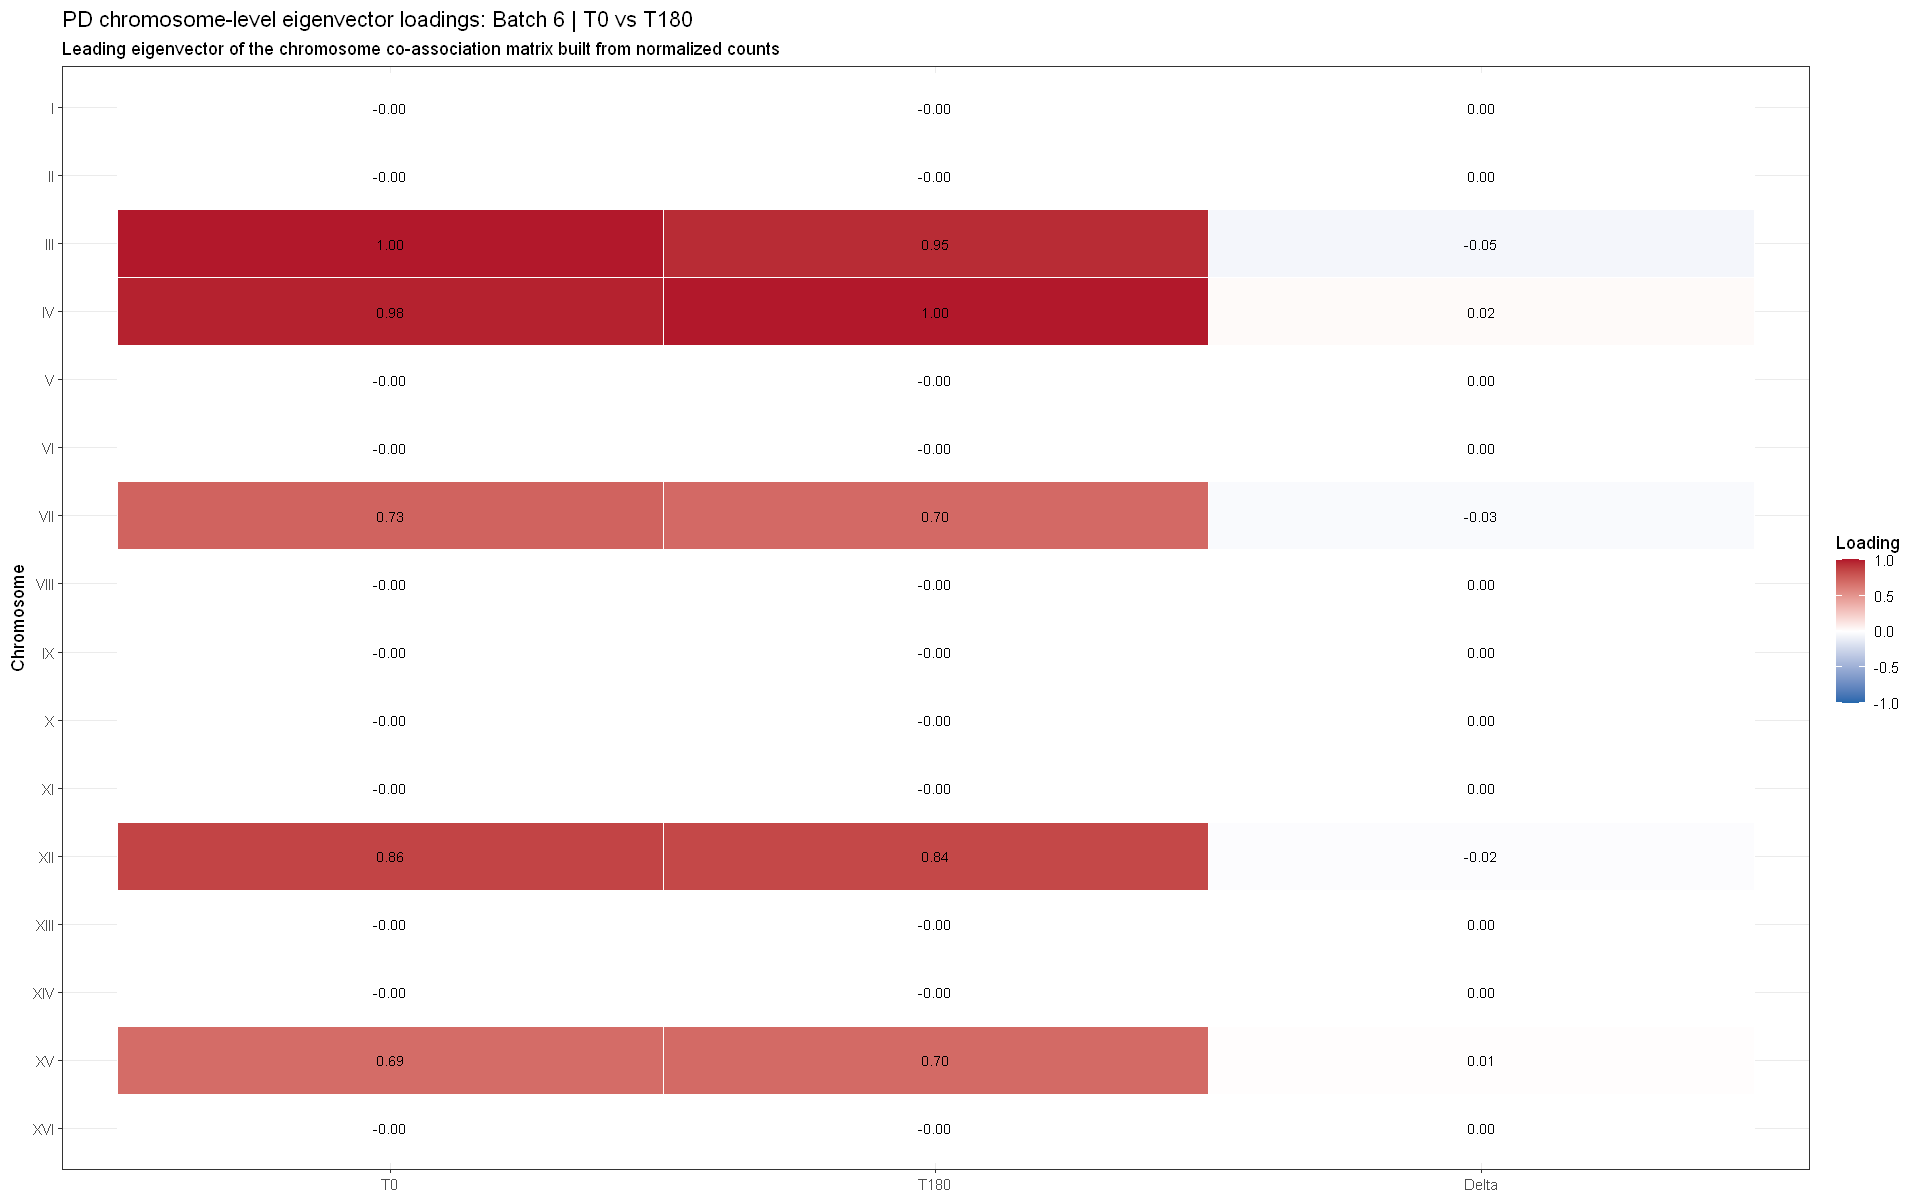

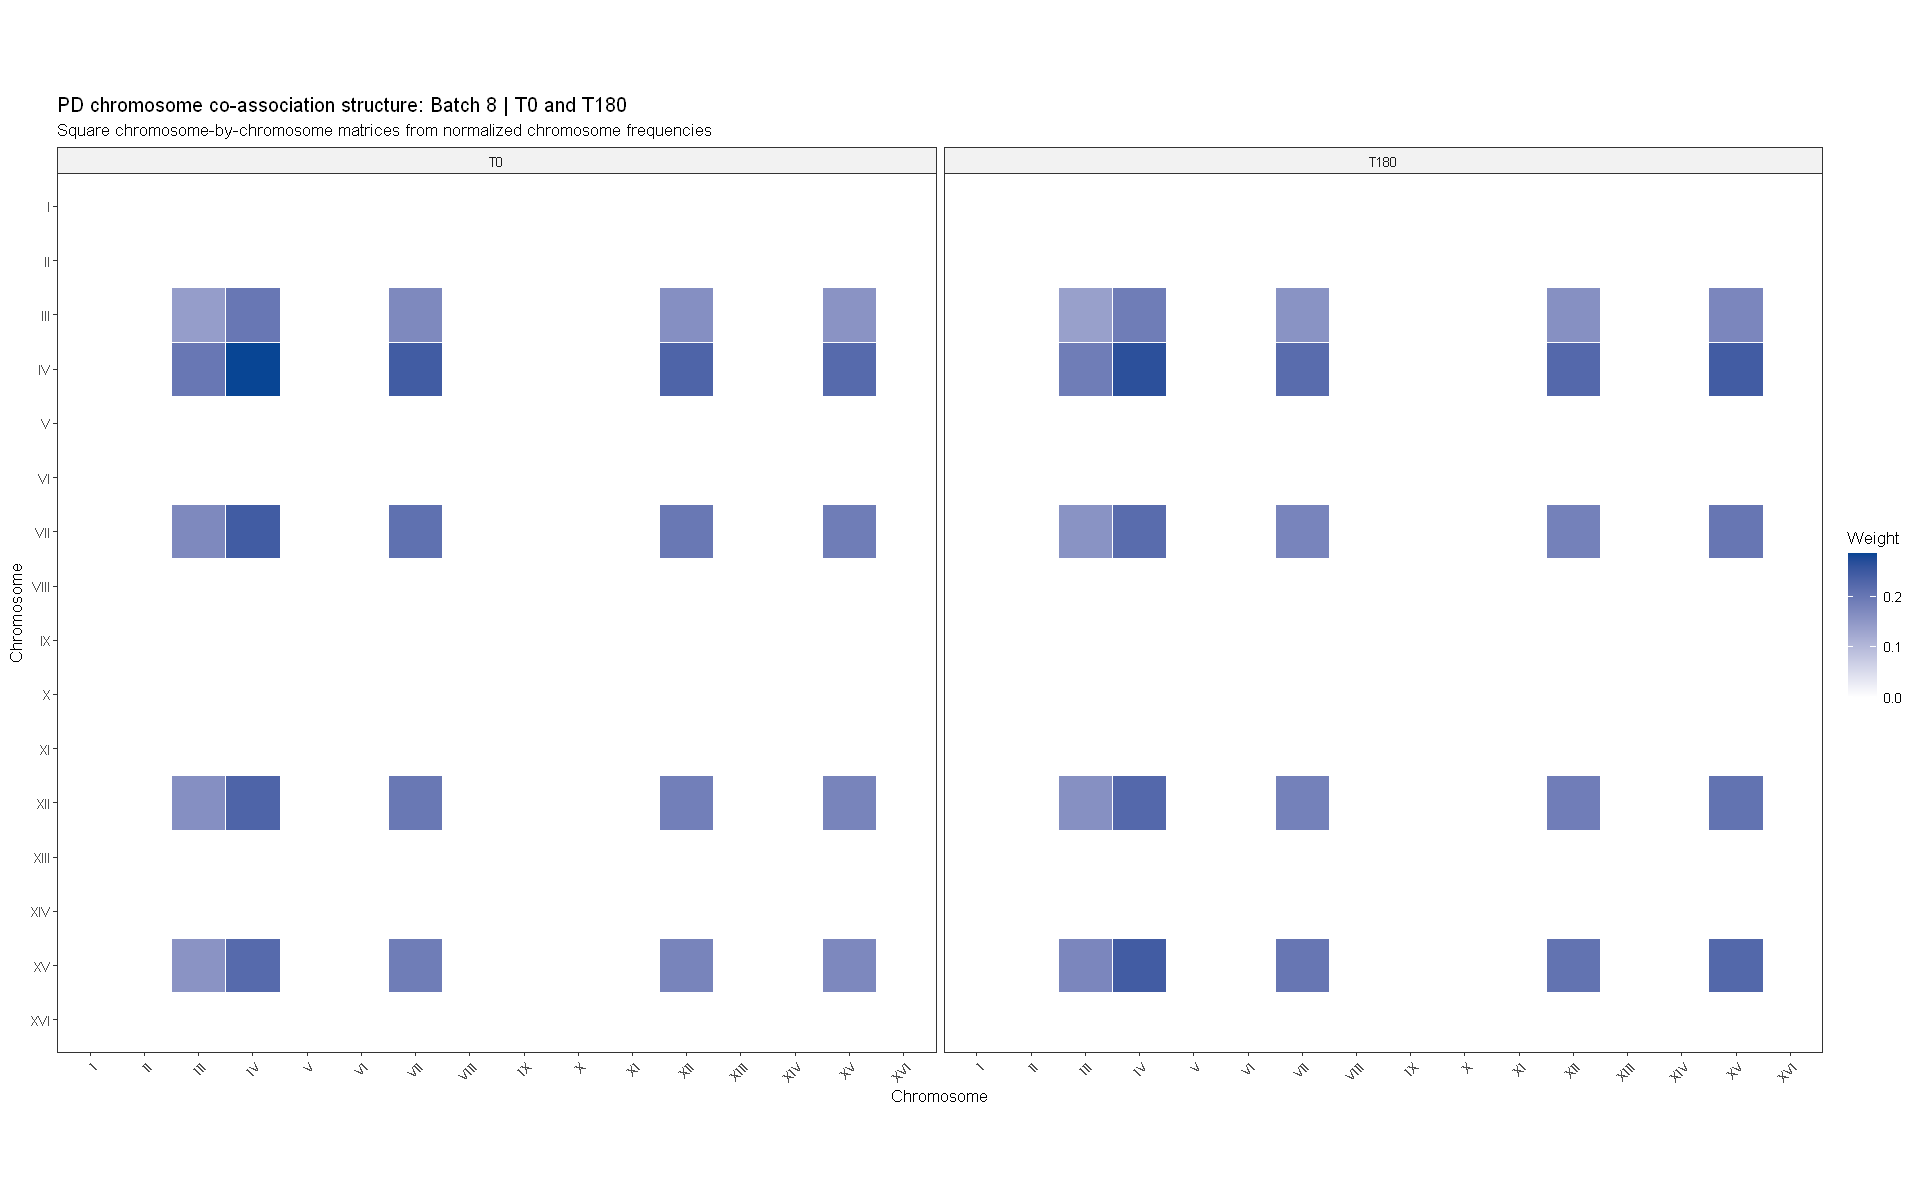

# A tibble: 16 × 10
   chromosome    T0 T0_Frequency  Tend Tend_Frequency   Delta abs_delta batch
   <fct>      <dbl>        <dbl> <dbl>          <dbl>   <dbl>     <dbl> <chr>
 1 XV         0.779        0.174 0.922          0.226  0.143     0.143  8    
 2 VII        0.860        0.211 0.823          0.180 -0.0370    0.0370 8    
 3 XII        0.811        0.188 0.847          0.191  0.0355    0.0355 8    
 4 III        0.704        0.141 0.719          0.137  0.0154    0.0154 8    
 5 I          0            0     0              0      0         0      8    
 6 II         0            0     0              0      0         0      8    
 7 IV         1            0.286 1              0.266  0         0      8    
 8 V          0            0     0              0      0         0      8    
 9 VI         0            0     0              0      0         0      8    
10 VIII       0            0     0              0      0         0      8    
11 IX         0            0     0          

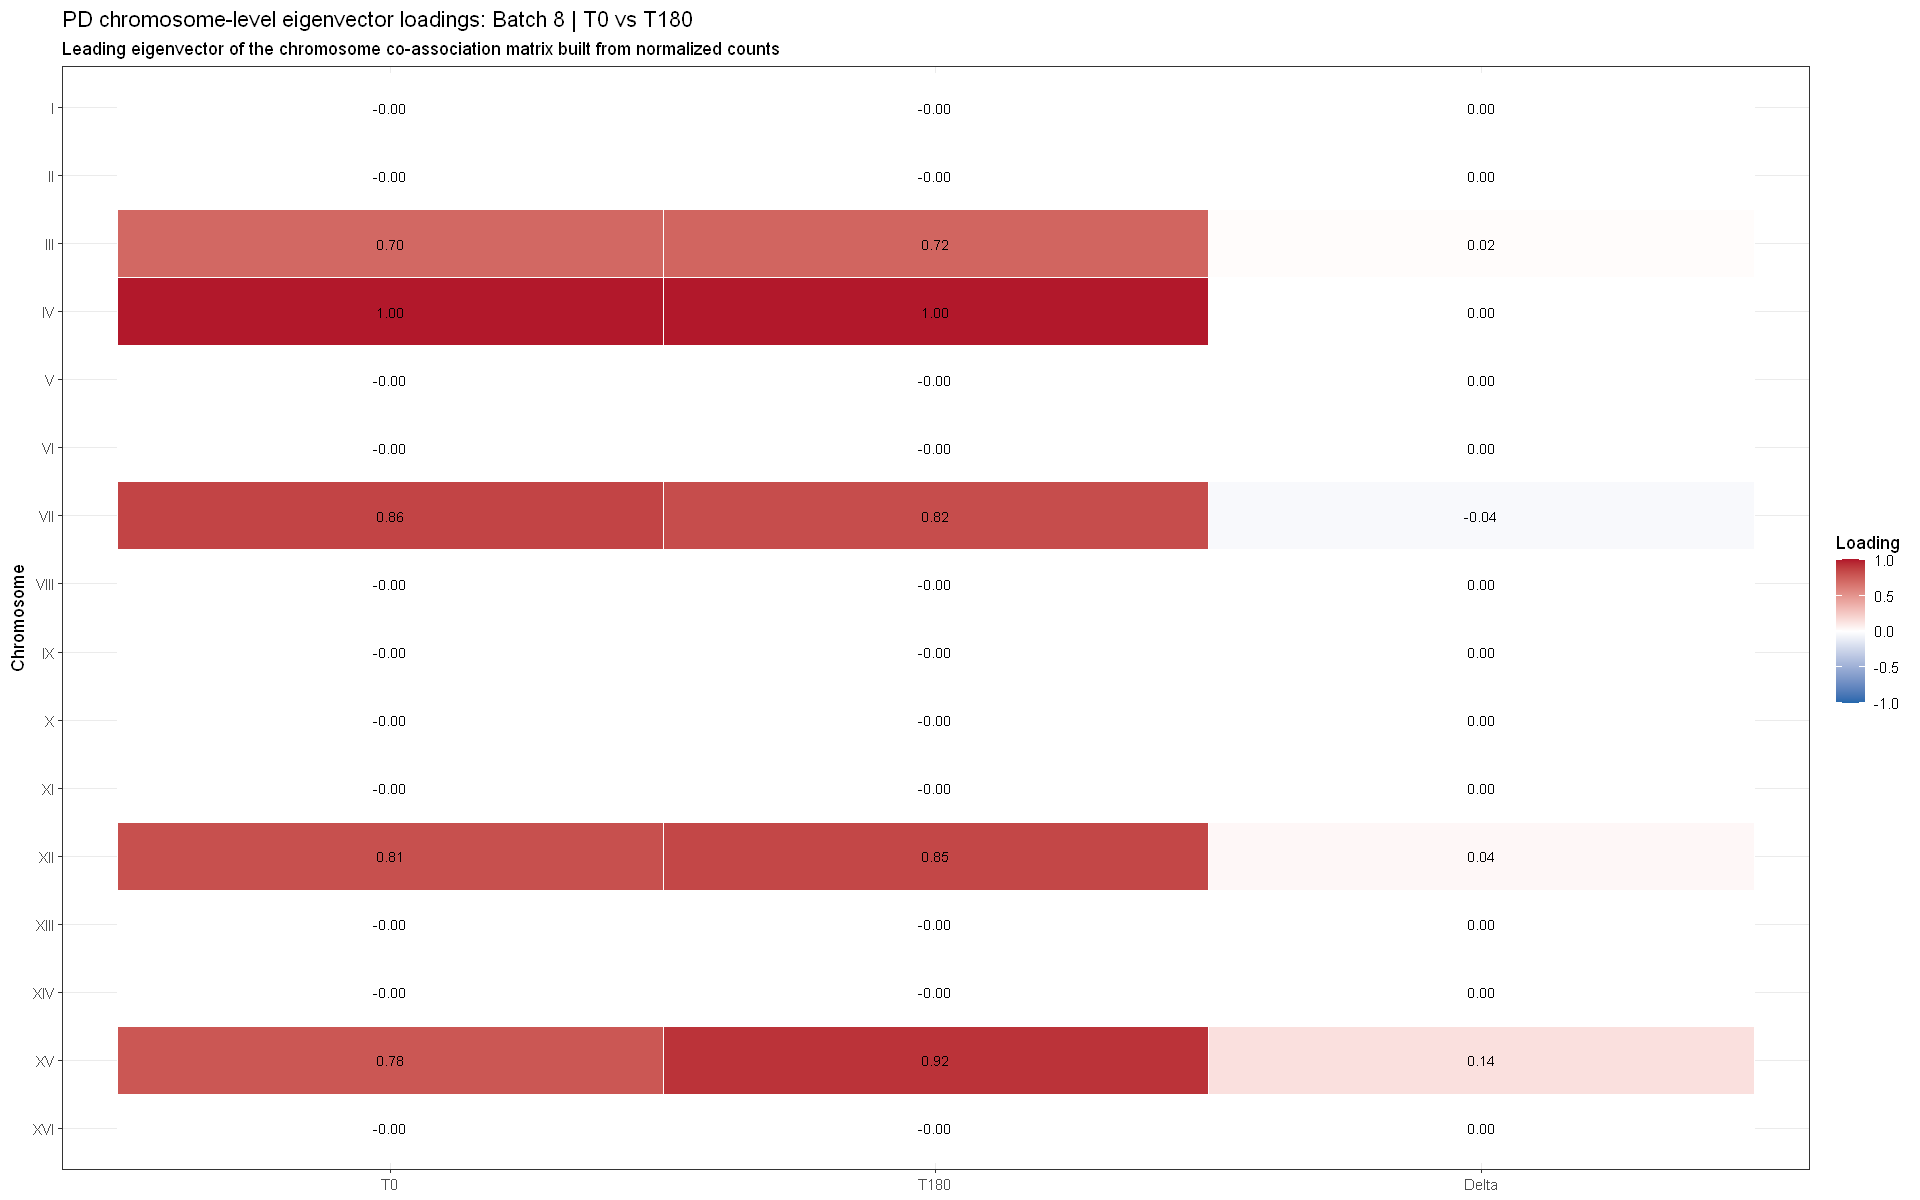

In [16]:
# ---- Eigenvector comparison heatmap: chromosome-level T0 vs T180 (batch-stratified) ----
p_eig_chr_pd <- list()
p_chr_structure_pd <- list()
eig_compare_pd <- tibble::tibble()
chr_matrix_t0_pd <- list()
chr_matrix_tend_pd <- list()

chr_levels_pd <- c('I','II','III','IV','V','VI','VII','VIII','IX','X','XI','XII','XIII','XIV','XV','XVI')

num_to_roman_pd <- function(x) {
  roman_map <- c('I','II','III','IV','V','VI','VII','VIII','IX','X','XI','XII','XIII','XIV','XV','XVI')
  xi <- suppressWarnings(as.integer(readr::parse_number(as.character(x))))
  ifelse(is.na(xi) | xi < 1 | xi > length(roman_map), as.character(x), roman_map[xi])
}

extract_chr_label_pd <- function(x) {
  x <- toupper(trimws(as.character(x)))
  x <- stringr::str_replace(x, '^CHR', '')
  tok <- stringr::str_extract(x, '^[A-Z0-9]+')
  tok <- ifelse(stringr::str_detect(tok, '^[0-9]+$'), num_to_roman_pd(tok), tok)
  ifelse(tok %in% chr_levels_pd, tok, NA_character_)
}

sanitize_batch_key_pd <- function(x) {
  x <- gsub('[^A-Za-z0-9]+', '_', as.character(x))
  x <- gsub('(^_+|_+$)', '', x)
  paste0('batch', x)
}

build_chr_eig_profile_pd <- function(df_in, time_value) {
  chr_counts <- df_in %>%
    dplyr::filter(time_point == time_value) %>%
    dplyr::mutate(chromosome = extract_chr_label_pd(allele)) %>%
    dplyr::filter(!is.na(chromosome)) %>%
    dplyr::group_by(chromosome) %>%
    dplyr::summarise(total_count = sum(count, na.rm = TRUE), .groups = 'drop') %>%
    tidyr::complete(chromosome = chr_levels_pd, fill = list(total_count = 0)) %>%
    dplyr::arrange(factor(chromosome, levels = chr_levels_pd))

  total_sum <- sum(chr_counts$total_count, na.rm = TRUE)
  freq <- if (is.finite(total_sum) && total_sum > 0) chr_counts$total_count / total_sum else rep(0, nrow(chr_counts))
  profile <- sqrt(freq)
  sim <- tcrossprod(profile)
  eig <- eigen(sim, symmetric = TRUE)
  load <- eig$vectors[, 1] * sqrt(max(Re(eig$values[1]), 0))
  if (sum(load * profile, na.rm = TRUE) < 0) load <- -load
  scale_fac <- max(abs(load), na.rm = TRUE)
  if (is.finite(scale_fac) && scale_fac > 0) load <- load / scale_fac

  tibble::tibble(
    chromosome = chr_counts$chromosome,
    loading = as.numeric(load),
    frequency = as.numeric(freq)
  )
}

if (exists('dat4') && is.data.frame(dat4) && nrow(dat4) > 0) {
  batch_levels_pd <- dat4 %>%
    dplyr::mutate(batch = as.character(batch), time_point = as.numeric(as.character(time_point))) %>%
    dplyr::filter(!is.na(batch), batch != '', is.finite(time_point)) %>%
    dplyr::group_by(batch) %>%
    dplyr::summarise(n_timepoints = dplyr::n_distinct(time_point), .groups = 'drop') %>%
    dplyr::filter(n_timepoints >= 2) %>%
    dplyr::pull(batch)

  if (length(batch_levels_pd) == 0) {
    message('Skipping PD eigenvector heatmap: no batch has paired baseline/endpoint coverage.')
  } else {
    for (batch_value in batch_levels_pd) {
      batch_key <- sanitize_batch_key_pd(batch_value)
      batch_df <- dat4 %>% dplyr::filter(as.character(batch) == batch_value)
      pd_timepoints <- sort(unique(as.numeric(as.character(batch_df$time_point))))
      pd_t0 <- pd_timepoints[1]
      pd_tend <- pd_timepoints[length(pd_timepoints)]

      eig_t0_pd <- build_chr_eig_profile_pd(batch_df, pd_t0) %>%
        dplyr::rename(T0 = loading, T0_Frequency = frequency)
      eig_tend_pd <- build_chr_eig_profile_pd(batch_df, pd_tend) %>%
        dplyr::rename(Tend = loading, Tend_Frequency = frequency)

      chr_matrix_t0_batch <- tcrossprod(sqrt(eig_t0_pd$T0_Frequency))
      rownames(chr_matrix_t0_batch) <- eig_t0_pd$chromosome
      colnames(chr_matrix_t0_batch) <- eig_t0_pd$chromosome

      chr_matrix_tend_batch <- tcrossprod(sqrt(eig_tend_pd$Tend_Frequency))
      rownames(chr_matrix_tend_batch) <- eig_tend_pd$chromosome
      colnames(chr_matrix_tend_batch) <- eig_tend_pd$chromosome

      structure_df_pd <- dplyr::bind_rows(
        as.data.frame(as.table(chr_matrix_t0_batch), stringsAsFactors = FALSE) %>%
          tibble::as_tibble() %>%
          dplyr::rename(Row = Var1, Column = Var2, Value = Freq) %>%
          dplyr::mutate(Comparison = 'T0'),
        as.data.frame(as.table(chr_matrix_tend_batch), stringsAsFactors = FALSE) %>%
          tibble::as_tibble() %>%
          dplyr::rename(Row = Var1, Column = Var2, Value = Freq) %>%
          dplyr::mutate(Comparison = paste0('T', pd_tend))
      ) %>%
        dplyr::mutate(
          Row = factor(Row, levels = rev(chr_levels_pd)),
          Column = factor(Column, levels = chr_levels_pd),
          Comparison = factor(Comparison, levels = c('T0', paste0('T', pd_tend)))
        )

      structure_lim_pd <- max(structure_df_pd$Value, na.rm = TRUE)
      if (!is.finite(structure_lim_pd) || structure_lim_pd <= 0) structure_lim_pd <- 0.1

      p_chr_structure_batch <- ggplot2::ggplot(structure_df_pd, ggplot2::aes(x = Column, y = Row, fill = Value)) +
        ggplot2::geom_tile(color = 'white', linewidth = 0.2) +
        ggplot2::facet_wrap(~Comparison, nrow = 1) +
        ggplot2::coord_equal() +
        ggplot2::scale_fill_gradient(low = 'white', high = '#084594', limits = c(0, structure_lim_pd)) +
        ggplot2::theme_bw(base_size = 10) +
        ggplot2::theme(
          panel.grid = ggplot2::element_blank(),
          axis.text.x = ggplot2::element_text(angle = 45, hjust = 1),
          strip.background = ggplot2::element_rect(fill = 'grey95')
        ) +
        ggplot2::labs(
          title = paste0('PD chromosome co-association structure: Batch ', batch_value, ' | T0 and T', pd_tend),
          subtitle = 'Square chromosome-by-chromosome matrices from normalized chromosome frequencies',
          x = 'Chromosome',
          y = 'Chromosome',
          fill = 'Weight'
        )
      print(p_chr_structure_batch)

      common_chr_pd <- intersect(eig_t0_pd$chromosome, eig_tend_pd$chromosome)
      cor_sign_pd <- suppressWarnings(stats::cor(
        eig_t0_pd$T0[match(common_chr_pd, eig_t0_pd$chromosome)],
        eig_tend_pd$Tend[match(common_chr_pd, eig_tend_pd$chromosome)],
        use = 'pairwise.complete.obs'
      ))
      if (is.finite(cor_sign_pd) && cor_sign_pd < 0) {
        eig_tend_pd <- eig_tend_pd %>% dplyr::mutate(Tend = -Tend)
      }

      eig_compare_batch <- eig_t0_pd %>%
        dplyr::left_join(eig_tend_pd, by = 'chromosome') %>%
        dplyr::mutate(
          Delta = Tend - T0,
          abs_delta = abs(Delta),
          chromosome = factor(chromosome, levels = rev(chr_levels_pd)),
          batch = as.character(batch_value),
          batch_key = batch_key,
          endpoint_time = pd_tend
        )

      heat_df_pd <- eig_compare_batch %>%
        dplyr::select(chromosome, T0, Tend, Delta) %>%
        tidyr::pivot_longer(cols = c(T0, Tend, Delta), names_to = 'Comparison', values_to = 'Loading') %>%
        dplyr::mutate(Comparison = factor(Comparison, levels = c('T0', 'Tend', 'Delta'), labels = c('T0', paste0('T', pd_tend), 'Delta')))

      heat_lim_pd <- max(abs(heat_df_pd$Loading), na.rm = TRUE)
      if (!is.finite(heat_lim_pd) || heat_lim_pd <= 0) heat_lim_pd <- 0.1

      p_eig_chr_batch <- ggplot2::ggplot(heat_df_pd, ggplot2::aes(x = Comparison, y = chromosome, fill = Loading)) +
        ggplot2::geom_tile(color = 'white', linewidth = 0.35) +
        ggplot2::geom_text(ggplot2::aes(label = sprintf('%.2f', Loading)), size = 3) +
        ggplot2::scale_fill_gradient2(low = '#2166ac', mid = 'white', high = '#b2182b', midpoint = 0, limits = c(-heat_lim_pd, heat_lim_pd)) +
        ggplot2::theme_bw(base_size = 11) +
        ggplot2::labs(
          title = paste0('PD chromosome-level eigenvector loadings: Batch ', batch_value, ' | T0 vs T', pd_tend),
          subtitle = 'Leading eigenvector of the chromosome co-association matrix built from normalized counts',
          x = NULL,
          y = 'Chromosome',
          fill = 'Loading'
        )
      print(p_eig_chr_batch)
      print(eig_compare_batch %>% dplyr::arrange(dplyr::desc(abs_delta)))

      p_chr_structure_pd[[batch_key]] <- p_chr_structure_batch
      p_eig_chr_pd[[batch_key]] <- p_eig_chr_batch
      chr_matrix_t0_pd[[batch_key]] <- chr_matrix_t0_batch
      chr_matrix_tend_pd[[batch_key]] <- chr_matrix_tend_batch
      eig_compare_pd <- dplyr::bind_rows(eig_compare_pd, eig_compare_batch)
    }
  }
} else {
  message('Skipping PD eigenvector heatmap: dat4 is unavailable or empty.')
}

In [ ]:
# ---- Save PD eigenvector outputs ----
eig_out_dir_pd <- file.path(getwd(), 'Outputs', 'PD')
dir.create(eig_out_dir_pd, recursive = TRUE, showWarnings = FALSE)

if (exists('p_chr_structure_pd') && is.list(p_chr_structure_pd) && length(p_chr_structure_pd) > 0) {
  for (batch_key in names(p_chr_structure_pd)) {
    batch_df <- eig_compare_pd %>% dplyr::filter(batch_key == !!batch_key)
    endpoint_time <- if (nrow(batch_df) > 0) unique(batch_df$endpoint_time)[1] else 'END'
    ggplot2::ggsave(
      filename = file.path(eig_out_dir_pd, paste0('PD_', batch_key, '_chromosome_structure_matrices_t0_t', endpoint_time, '.png')),
      plot = p_chr_structure_pd[[batch_key]],
      width = 12,
      height = 6.5,
      dpi = 220
    )
  }
}

if (exists('chr_matrix_t0_pd') && is.list(chr_matrix_t0_pd) && length(chr_matrix_t0_pd) > 0) {
  for (batch_key in names(chr_matrix_t0_pd)) {
    readr::write_csv(
      tibble::rownames_to_column(as.data.frame(chr_matrix_t0_pd[[batch_key]]), var = 'chromosome'),
      file.path(eig_out_dir_pd, paste0('PD_', batch_key, '_chromosome_structure_matrix_t0.csv'))
    )
  }
}

if (exists('chr_matrix_tend_pd') && is.list(chr_matrix_tend_pd) && length(chr_matrix_tend_pd) > 0) {
  for (batch_key in names(chr_matrix_tend_pd)) {
    batch_df <- eig_compare_pd %>% dplyr::filter(batch_key == !!batch_key)
    endpoint_time <- if (nrow(batch_df) > 0) unique(batch_df$endpoint_time)[1] else 'END'
    readr::write_csv(
      tibble::rownames_to_column(as.data.frame(chr_matrix_tend_pd[[batch_key]]), var = 'chromosome'),
      file.path(eig_out_dir_pd, paste0('PD_', batch_key, '_chromosome_structure_matrix_t', endpoint_time, '.csv'))
    )
  }
}

if (exists('p_eig_chr_pd') && is.list(p_eig_chr_pd) && length(p_eig_chr_pd) > 0) {
  for (batch_key in names(p_eig_chr_pd)) {
    batch_df <- eig_compare_pd %>% dplyr::filter(batch_key == !!batch_key)
    endpoint_time <- if (nrow(batch_df) > 0) unique(batch_df$endpoint_time)[1] else 'END'
    ggplot2::ggsave(
      filename = file.path(eig_out_dir_pd, paste0('PD_', batch_key, '_chromosome_eigenvector_heatmap_t0_t', endpoint_time, '.png')),
      plot = p_eig_chr_pd[[batch_key]],
      width = 7,
      height = 7.5,
      dpi = 220
    )
  }
}

if (exists('eig_compare_pd') && is.data.frame(eig_compare_pd) && nrow(eig_compare_pd) > 0) {
  split(eig_compare_pd, eig_compare_pd$batch_key) %>%
    purrr::iwalk(~ {
      endpoint_time <- unique(.x$endpoint_time)[1]
      readr::write_csv(
        .x %>% dplyr::mutate(chromosome = as.character(chromosome)),
        file.path(eig_out_dir_pd, paste0('PD_', .y, '_chromosome_eigenvector_loadings_t0_t', endpoint_time, '.csv'))
      )
    })

  readr::write_csv(
    eig_compare_pd %>% dplyr::mutate(chromosome = as.character(chromosome)),
    file.path(eig_out_dir_pd, 'PD_chromosome_eigenvector_loadings_by_batch.csv')
  )
}

In [14]:
# ---- Optional: save all plots for sharing ----
out_dir <- file.path(getwd(), 'Outputs', 'PD')
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# Priority early line plots
if (exists('p_early_cistrans') && !is.null(p_early_cistrans)) {
  ggsave(file.path(out_dir, 'PD_priority_cis_trans_line.png'),
         plot = p_early_cistrans, width = 13, height = 5.5, dpi = 220)
}
if (exists('p_early_repair') && !is.null(p_early_repair)) {
  ggsave(file.path(out_dir, 'PD_priority_intact_repair_ssa_line.png'),
         plot = p_early_repair, width = 13, height = 5.5, dpi = 220)
}

# QC plots
ggsave(file.path(out_dir, 'PD_QC_total_counts.png'),
       plot = p_total, width = 12, height = 6, dpi = 200)
ggsave(file.path(out_dir, 'PD_QC_cis_trans_percent.png'),
       plot = p_cistrans, width = 14, height = 8, dpi = 200)

# Chromosome map
if (exists('p_chrom_map') && !is.null(p_chrom_map)) {
  ggsave(file.path(out_dir, 'PD_DSB_chromosome_map.png'),
         plot = p_chrom_map, width = 16, height = 10, dpi = 220)
}

# TRANS heatmap
if (exists('p_trans_heatmap') && !is.null(p_trans_heatmap)) {
  ggsave(file.path(out_dir, 'PD_TRANS_repair_heatmap.png'),
         plot = p_trans_heatmap, width = 13, height = 8, dpi = 220)
}

# Circos plot (base graphics — captured with png device)
if (exists('has_circlize') && has_circlize && nrow(dsb_locs) > 0) {
  png(file.path(out_dir, 'PD_circos_TRANS_associations.png'),
      width = 2400, height = 2400, res = 200)
  # Re-run circos draw (circlize state is not stored in a ggplot object)
  # Source the circos cell manually or re-execute the circos code block if needed.
  dev.off()
  message('Circos PNG placeholder created; re-run the circos cell with png() open to capture.')
}

# Integrated PD + 3C plots
if (exists('p_contact_map_integrated') && !is.null(p_contact_map_integrated)) {
  ggsave(file.path(out_dir, 'PD_3C_integrated_contact_map.png'),
         plot = p_contact_map_integrated, width = 14, height = 8, dpi = 200)
}
if (exists('p_contact_map_compare') && !is.null(p_contact_map_compare)) {
  ggsave(file.path(out_dir, 'PD_3C_contact_map_comparison.png'),
         plot = p_contact_map_compare, width = 16, height = 10, dpi = 200)
}
if (exists('p_pd3c_assoc') && !is.null(p_pd3c_assoc)) {
  ggsave(file.path(out_dir, 'PD_3C_association_concordance_rsq.png'),
         plot = p_pd3c_assoc, width = 12, height = 8, dpi = 200)
}
if (exists('p_diff_contact_map') && !is.null(p_diff_contact_map)) {
  ggsave(file.path(out_dir, 'PD_3C_differential_contact_map_cut_minus_uncut.png'),
         plot = p_diff_contact_map, width = 14, height = 8, dpi = 200)
}
if (exists('p_rank_shift') && !is.null(p_rank_shift)) {
  ggsave(file.path(out_dir, 'PD_3C_rank_shift_slopegraph.png'),
         plot = p_rank_shift, width = 13, height = 8, dpi = 200)
}
if (exists('p_pd3c_residual_map') && !is.null(p_pd3c_residual_map)) {
  ggsave(file.path(out_dir, 'PD_3C_residual_map.png'),
         plot = p_pd3c_residual_map, width = 16, height = 10, dpi = 200)
}

message('Plots saved to: ', out_dir)

Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_text()`)."
Plots saved to: c:/Users/dunnmk/wilsontew-data-analysis/notebooks/full_analysis_notebooks/Outputs/PD



## Final interpretation alignment (pooled design aware)

This notebook should follow the same project-wide design constraints:

- Pooled 20+ strains with **variable DSB1 by strain**.
- **Batch-specific DSB2 anchors**: batch 4 = Chr VII, batch 6 = Chr IV, batch 8 = Chr XV.
- Baseline is pre-induction fixation; induced endpoint is interpreted as post-induction state.

### Guardrails

1. Do not combine batch-specific DSB2 contexts into a single biological anchor claim.
2. Interpret cis/trans and locus-ranking shifts within matched batch and state.
3. Cross-batch aggregates are descriptive unless modeled with explicit batch-anchor terms.

### Reporting statement

Final claims from this notebook should be phrased as **batch-specific DSB2-anchor results** in the pooled-strain framework.